# Effect-Size Visualization

Visualization-only notebook that loads pre-computed effect-size CSVs and produces flexible plots.

**Inputs:** the per-KD CSV folders written by `compute_effect_size.ipynb`:
```
<RESULTS_DIR>/<KD>/<KD>_<control>_effect_sizes.csv         # per-batch
<RESULTS_DIR>/<KD>/<KD>_<control>_weighted_effect_sizes.csv # weighted across batches
```

**What you can configure per plot** (any combination):
- which `markers`, `kds`, `controls`, `cell_lines`, `batches` to include
- which column goes on which axis (`x`, `y`, `hue`, `value`)
- positive-only clipping, color scale, sort order

All plotting helpers are pure functions of a tidy DataFrame, so you can mix them freely.

## 1. Setup

In [1]:
import os
import re
import ast
import glob
from typing import Iterable, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

In [2]:
# ---- Paths ---------------------------------------------------------------
EXPERIMENT_NAME = "fuNOVA_Screen"
PLATE_NUM = 3
REMOVE_OUTLIERS = True

NOVA_LOCAL = "/home/projects/hornsteinlab/Collaboration/Guy_Lior"
RESULTS_DIR = os.path.join(NOVA_LOCAL, EXPERIMENT_NAME, "Effect_size", f"plate{PLATE_NUM}")
if REMOVE_OUTLIERS:
    RESULTS_DIR = os.path.join(RESULTS_DIR, "after_outlier_removal")

PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
print("Reading CSVs from:", RESULTS_DIR)
print("Saving plots to:  ", PLOTS_DIR)

Reading CSVs from: /home/projects/hornsteinlab/Collaboration/Guy_Lior/fuNOVA_Screen/Effect_size/plate3/after_outlier_removal
Saving plots to:   /home/projects/hornsteinlab/Collaboration/Guy_Lior/fuNOVA_Screen/Effect_size/plate3/after_outlier_removal/plots


In [3]:
# ---- Marker grouping (used for sorting / labelling only) -----------------
FUNCTIONAL_MARKER_GROUPS = {
    "TDP-43 pathology": ["TDP-43", "pTDP-43"],
    "Stress Granules":  ["G3BP1"],
    "Proteostasis_ER":  ["ATF6", "Calreticulin"],
    "Proteostasis_Deg": ["p62", "pS6", "Aggreagtes"],
    "Mitochondria":     ["pAMPK"],
    "Cell Death":       ["Cas3"],
}
MARKER_TO_GROUP = {m: g for g, ms in FUNCTIONAL_MARKER_GROUPS.items() for m in ms}

In [4]:
# fixed colors for controls:
CONTROL_COLORS = {
    f"non-targeting-00004-00017-p{PLATE_NUM}": "blue",
    f"non-targeting-00010-00031-p{PLATE_NUM}": "green",
    f"non-targeting-00035-00050-p{PLATE_NUM}": "orange",
    f"non-targeting-00053-00059-p{PLATE_NUM}": "purple",
    f"non-targeting-00111-00121-p{PLATE_NUM}": "brown",
}

    

## 2. Loader

Walks `RESULTS_DIR`, parses every `*_effect_sizes.csv` and `*_weighted_effect_sizes.csv`, and returns a tidy long DataFrame:

| column | meaning |
|---|---|
| `kd`            | knockdown (subdir name) |
| `control`       | non-targeting condition (parsed from filename) |
| `cell_line`     | from `baseline` (`C9` / `CTL` / ...) |
| `marker`        | marker channel |
| `batch`         | per-batch row, or `"weighted"` for the cross-batch weighted value |
| `effect_size`   | scalar effect size for that row |
| `n_baseline`    | sample count baseline (NaN for `"weighted"` rows) |
| `n_pert`        | sample count perturbation (NaN for `"weighted"` rows) |
| `baseline`      | raw baseline label, e.g. `C9_non-targeting-00004-00017-p4` |
| `pert`          | raw perturbation label, e.g. `C9_AKIRIN2` |

In [5]:
_PER_BATCH_RE  = re.compile(r"^(?P<kd>.+?)_(?P<control>.+?)_effect_sizes\.csv$")
_WEIGHTED_RE   = re.compile(r"^(?P<kd>.+?)_(?P<control>.+?)_weighted_effect_sizes\.csv$")
_WEIGHTED_NOCTL_RE = re.compile(r"^(?P<kd>.+?)_weighted_effect_sizes\.csv$")

def _parse_effect_cell(x):
    """`effect_size` is stored as the string '[0.0035]'. Return the float."""
    if isinstance(x, (int, float, np.floating)):
        return float(x)
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            return float(v[0]) if isinstance(v, (list, tuple)) else float(v)
        except (ValueError, SyntaxError):
            return np.nan
    return np.nan

def load_all_effect_sizes(results_dir: str) -> pd.DataFrame:
    """Walk every KD subdir of `results_dir` and concatenate per-batch + weighted rows."""
    rows = []
    for kd in sorted(os.listdir(results_dir)):
        kd_dir = os.path.join(results_dir, kd)
        if not os.path.isdir(kd_dir) or kd in {"plots", "All_KDs_VS_NT-1873"}:
            continue

        # --- per-batch CSVs ---
        for csv_path in glob.glob(os.path.join(kd_dir, "*_effect_sizes.csv")):
            fname = os.path.basename(csv_path)
            if "_weighted_" in fname:
                continue
            m = _PER_BATCH_RE.match(fname)
            control = m.group("control") if m else None
            df = pd.read_csv(csv_path)
            df["effect_size"] = df["effect_size"].apply(_parse_effect_cell)
            df["kd"] = kd
            df["control"] = control
            df["cell_line"] = df["baseline"].str.split("_").str[0]
            rows.append(df[["kd", "control", "cell_line", "marker", "batch",
                            "effect_size", "n_baseline", "n_pert", "baseline", "pert"]])

        # --- weighted CSVs ---
        for csv_path in glob.glob(os.path.join(kd_dir, "*_weighted_effect_sizes.csv")):
            fname = os.path.basename(csv_path)
            m = _WEIGHTED_RE.match(fname) or _WEIGHTED_NOCTL_RE.match(fname)
            control = m.group("control") if (m and "control" in m.groupdict()) else None
            df = pd.read_csv(csv_path)
            df = df.rename(columns={"weighted_effect_size": "effect_size"})
            df["kd"] = kd
            df["control"] = control
            df["cell_line"] = df["baseline"].str.split("_").str[0]
            df["batch"] = "weighted"
            df["n_baseline"] = np.nan
            df["n_pert"] = np.nan
            rows.append(df[["kd", "control", "cell_line", "marker", "batch",
                            "effect_size", "n_baseline", "n_pert", "baseline", "pert"]])

    if not rows:
        raise FileNotFoundError(f"No effect-size CSVs found under {results_dir}")
    out = pd.concat(rows, ignore_index=True)
    out["functional_group"] = out["marker"].map(MARKER_TO_GROUP).fillna("Other")
    return out

data = load_all_effect_sizes(RESULTS_DIR)
print(f"Loaded {len(data):,} rows.")
print("  KDs:        ", sorted(data['kd'].unique())[:5], "...", f"({data['kd'].nunique()} total)")
print("  Markers:    ", sorted(data['marker'].unique()))
print("  Cell lines: ", sorted(data['cell_line'].unique()))
print("  Batches:    ", sorted(data['batch'].unique()))
print("  Controls:   ", sorted(data['control'].dropna().unique()))
data.head()

Loaded 4,730 rows.
  KDs:         ['ANXA11', 'ASRGL1', 'ATF7IP', 'BSN', 'CSNK1E'] ... (43 total)
  Markers:     ['ATF6', 'Aggreagtes', 'Calreticulin', 'Cas3', 'G3BP1', 'TDP-43', 'p62', 'pAMPK', 'pS6', 'pTDP-43']
  Cell lines:  ['C9']
  Batches:     ['batch1', 'weighted']
  Controls:    ['non-targeting-00004-00017-p3', 'non-targeting-00010-00031-p3', 'non-targeting-00035-00050-p3', 'non-targeting-00053-00059-p3', 'non-targeting-00111-00121-p3']


,kd,control,cell_line,marker,batch,effect_size,n_baseline,n_pert,baseline,pert,functional_group
0,ANXA11,non-targeting-00111-00121-p3,C9,ATF6,batch1,0.008667,336.0,552.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Proteostasis_ER
1,ANXA11,non-targeting-00111-00121-p3,C9,Aggreagtes,batch1,0.054583,360.0,511.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Proteostasis_Deg
2,ANXA11,non-targeting-00111-00121-p3,C9,Calreticulin,batch1,-0.000822,527.0,441.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Proteostasis_ER
3,ANXA11,non-targeting-00111-00121-p3,C9,Cas3,batch1,0.036367,360.0,512.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Cell Death
4,ANXA11,non-targeting-00111-00121-p3,C9,G3BP1,batch1,-0.009554,527.0,441.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Stress Granules


## 2.5 Plate-outline flag

Each entry (batch, cell_line, kd, marker) corresponds to a set of wells on the screening plate.
We scan the input image directory and flag entries whose wells fall on the plate outline
(row 1, row 16, col 1, or col 24 on a 384-well plate). Edge wells often suffer from evaporation
and other position-dependent artefacts, so this flag lets you filter or annotate outline entries
in downstream plots.

The well coordinates are parsed from the `.npy` filenames, e.g. `rep1_r09c23f64-...` ⇒ row 9, col 23.
KD-name mapping: data uses dashes (`Empty-p4`), input dirs use underscores (`Empty_p4`).

In [6]:
# ---- Plate-outline annotation -------------------------------------------
INPUT_ROOT = "/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/FuNOVA_Screen"
PLATE_ROWS = 16   # 384-well plate
PLATE_COLS = 24

_WELL_RE = re.compile(r"r(\d{1,2})c(\d{1,2})")

def is_well_on_outline(row: int, col: int,
                       n_rows: int = PLATE_ROWS, n_cols: int = PLATE_COLS) -> bool:
    return row == 1 or row == n_rows or col == 1 or col == n_cols

def _kd_to_dirname(kd: str) -> str:
    """Data uses dashes (e.g. 'Empty-p4'); image dirs use underscores ('Empty_p4')."""
    if "TDP-43" in kd:
        print(kd)
        plate = kd.split("-")[2]
        new_name = f"TDP-43_{plate}"
        print(f"Renaming to {new_name}")
        return new_name
    return kd.replace("-", "_")

def _wells_for_entry(batch: str, cell_line: str, kd: str, marker: str) -> set:
    """Scan the marker subdir and return the set of (row, col) wells found."""
    kd_dir = _kd_to_dirname(kd)
    dir_path = os.path.join(INPUT_ROOT, batch, cell_line, kd_dir, marker)
    if not os.path.isdir(dir_path):
        return set()
    wells = set()
    for fname in os.listdir(dir_path):
        m = _WELL_RE.search(fname)
        if m:
            wells.add((int(m.group(1)), int(m.group(2))))
    return wells

def annotate_plate_outline(df: pd.DataFrame,
                           input_root: str = INPUT_ROOT,
                           fallback_batch: str = "batch1") -> pd.DataFrame:
    """Add `on_plate_outline`, `n_wells`, `n_wells_on_outline` columns.

    `on_plate_outline` is True if ANY well used for that (batch, cell_line, kd, marker)
    entry sits on the plate outline. For `batch == "weighted"` rows, wells are looked
    up under `fallback_batch` (the wells are the same across batches in this layout).
    """
    keys = df[["batch", "cell_line", "kd", "marker"]].drop_duplicates()
    cache = {}
    for _, k in keys.iterrows():
        batch_for_lookup = fallback_batch if k.batch == "weighted" else k.batch
        cache[(k.batch, k.cell_line, k.kd, k.marker)] = _wells_for_entry(
            batch_for_lookup, k.cell_line, k.kd, k.marker
        )

    def _summarise(row):
        wells = cache.get((row.batch, row.cell_line, row.kd, row.marker), set())
        n_total = len(wells)
        n_outline = sum(is_well_on_outline(r, c) for r, c in wells)
        return pd.Series({
            "n_wells": n_total,
            "n_wells_on_outline": n_outline,
            "on_plate_outline": n_outline > 0 if n_total > 0 else np.nan,
        })

    annot = df.apply(_summarise, axis=1)
    return pd.concat([df, annot], axis=1)

data = annotate_plate_outline(data)
missing = data[data["n_wells"] == 0][["batch", "cell_line", "kd", "marker"]].drop_duplicates()
print(f"Annotated {len(data):,} rows.")
print(f"  on_plate_outline=True : {int((data['on_plate_outline'] == True).sum()):,}")
print(f"  on_plate_outline=False: {int((data['on_plate_outline'] == False).sum()):,}")
if not missing.empty:
    print(f"  No image dir found for {len(missing)} (batch,cell_line,kd,marker) combos:")
    print(missing.head(10).to_string(index=False))
data.head()

TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
TDP-43-p3
Renaming to TDP-43_p3
Annotated 4,730 rows.
  on_plate_outline=True : 1,265
  on_plate_outline=False: 3,465


,kd,control,cell_line,marker,batch,effect_size,n_baseline,n_pert,baseline,pert,functional_group,n_wells,n_wells_on_outline,on_plate_outline
0,ANXA11,non-targeting-00111-00121-p3,C9,ATF6,batch1,0.008667,336.0,552.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Proteostasis_ER,2,0,False
1,ANXA11,non-targeting-00111-00121-p3,C9,Aggreagtes,batch1,0.054583,360.0,511.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Proteostasis_Deg,2,0,False
2,ANXA11,non-targeting-00111-00121-p3,C9,Calreticulin,batch1,-0.000822,527.0,441.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Proteostasis_ER,2,0,False
3,ANXA11,non-targeting-00111-00121-p3,C9,Cas3,batch1,0.036367,360.0,512.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Cell Death,2,0,False
4,ANXA11,non-targeting-00111-00121-p3,C9,G3BP1,batch1,-0.009554,527.0,441.0,C9_non-targeting-00111-00121-p3,C9_ANXA11,Stress Granules,2,0,False


## 3. Filter helper

Pass any combination of `markers=`, `kds=`, `controls=`, `cell_lines=`, `batches=`. `None` (the default) means "keep all".

`clip_negative=True` clips `effect_size` to `>=0` (matches the original notebook's behaviour for the heatmaps).

In [7]:
def filter_data(
    df: pd.DataFrame,
    markers:    Optional[Sequence[str]] = None,
    kds:        Optional[Sequence[str]] = None,
    controls:   Optional[Sequence[str]] = None,
    cell_lines: Optional[Sequence[str]] = None,
    batches:    Optional[Sequence[str]] = None,
    exclude_markers: Optional[Sequence[str]] = None,
    clip_negative: bool = False,
    exclude_empty: bool = True,   # drop "Empty*" KDs (the empty-well positive controls)
) -> pd.DataFrame:
    out = df.copy()
    if markers    is not None: out = out[out["marker"].isin(markers)]
    if kds        is not None: out = out[out["kd"].isin(kds)]
    if controls   is not None: out = out[out["control"].isin(controls)]
    if cell_lines is not None: out = out[out["cell_line"].isin(cell_lines)]
    if batches    is not None: out = out[out["batch"].isin(batches)]
    if exclude_markers:        out = out[~out["marker"].isin(exclude_markers)]
    if exclude_empty:          out = out[~out["kd"].str.startswith("Empty")]
    if clip_negative:          out = out.assign(effect_size=out["effect_size"].clip(lower=0))
    return out.reset_index(drop=True)

## 4. Flexible heatmap

Pick any column for the rows (`y=`), columns (`x=`) and the cell value (`value=`).
Common picks:

| `y` | `x` | `value` | what it shows |
|---|---|---|---|
| `marker` | `kd` | `effect_size` | classic per-marker × per-KD heatmap |
| `kd` | `marker` | `effect_size` | transposed |
| `marker` | `control` | `effect_size` | which control gives the strongest signal |
| `kd` | `cell_line` | `effect_size` | KD effect by cell line for one marker |

In [8]:
from matplotlib.patches import Rectangle

def plot_heatmap(
    df: pd.DataFrame,
    x: str = "kd",
    y: str = "marker",
    value: str = "effect_size",
    aggfunc="mean",
    vmin: Optional[float] = 0.0,
    vmax: Optional[float] = 0.4,
    cmap: str = "RdBu_r",
    sort_markers_by_group: bool = True,
    sort_cols_by: Optional[str] = None,   # e.g. "mean", "max"
    figsize=(12, 6),
    title: Optional[str] = None,
    mask_abs_below: Optional[float] = None,   # white-out cells with |value| < threshold
    grey_outline: bool = False,               # hatch cells where on_plate_outline=True
    save_as: Optional[str] = None,
):
    if df.empty:
        print("No data to plot.")
        return None
    pivot = df.pivot_table(index=y, columns=x, values=value, aggfunc=aggfunc)

    if sort_markers_by_group and y == "marker":
        order = sorted(pivot.index, key=lambda m: (MARKER_TO_GROUP.get(m, "Other"), m))
        pivot = pivot.reindex(order)
    if sort_markers_by_group and x == "marker":
        order = sorted(pivot.columns, key=lambda m: (MARKER_TO_GROUP.get(m, "Other"), m))
        pivot = pivot[order]
    if sort_cols_by in {"mean", "max", "sum"}:
        order = pivot.agg(sort_cols_by, axis=0).sort_values(ascending=False).index
        pivot = pivot[order]

    # Outline overlay aligned to pivot
    outline_pivot = None
    if grey_outline and "on_plate_outline" in df.columns:
        outline_pivot = (df.assign(_o=df["on_plate_outline"].fillna(False).astype(bool))
                           .pivot_table(index=y, columns=x, values="_o", aggfunc="any"))
        outline_pivot = outline_pivot.reindex(index=pivot.index, columns=pivot.columns).fillna(False)

    # White-out cells whose |value| is below threshold
    plot_pivot = pivot.copy()
    if mask_abs_below is not None:
        plot_pivot = plot_pivot.mask(plot_pivot.abs() < mask_abs_below)

    cbar_label = value if mask_abs_below is None else f"{value}  (|x|<{mask_abs_below} masked)"

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        plot_pivot, ax=ax, cmap=cmap, center=0,
        vmin=vmin, vmax=vmax,
        cbar_kws={"label": cbar_label},
    )

    # Mark threshold on the colorbar
    if mask_abs_below is not None:
        cbar = ax.collections[0].colorbar
        if cbar is not None:
            lo, hi = cbar.ax.get_ylim()
            for thr in (mask_abs_below, -mask_abs_below):
                if min(lo, hi) <= thr <= max(lo, hi):
                    cbar.ax.axhline(thr, color="k", linewidth=1)

    # Hatch overlay on outline cells
    if outline_pivot is not None:
        for i, row_label in enumerate(plot_pivot.index):
            for j, col_label in enumerate(plot_pivot.columns):
                if bool(outline_pivot.loc[row_label, col_label]):
                    ax.add_patch(Rectangle(
                        (j, i), 1, 1, fill=False,
                        hatch="///", edgecolor="dimgrey", linewidth=0,
                    ))

    ax.set_title(title or f"{value} ({aggfunc}) by {y} × {x}")
    ax.set_xlabel(x); ax.set_ylabel(y)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_as:
        fig.savefig(os.path.join(PLOTS_DIR, save_as), dpi=200, bbox_inches="tight")
    plt.show()
    return fig, ax, pivot


--- Control: non-targeting-00004-00017-p3 ---


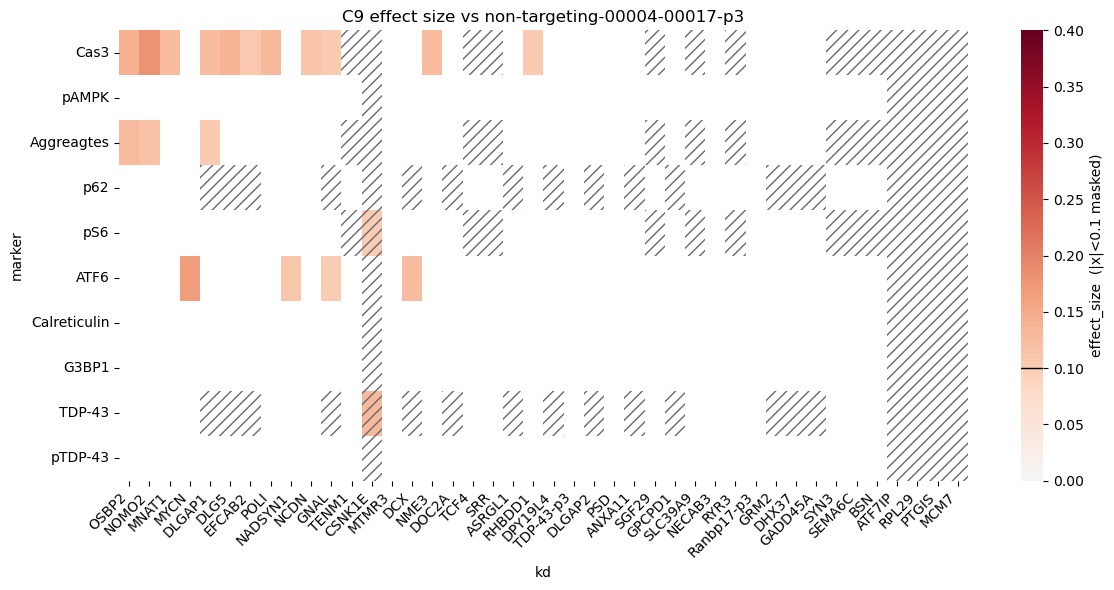


--- Control: non-targeting-00010-00031-p3 ---


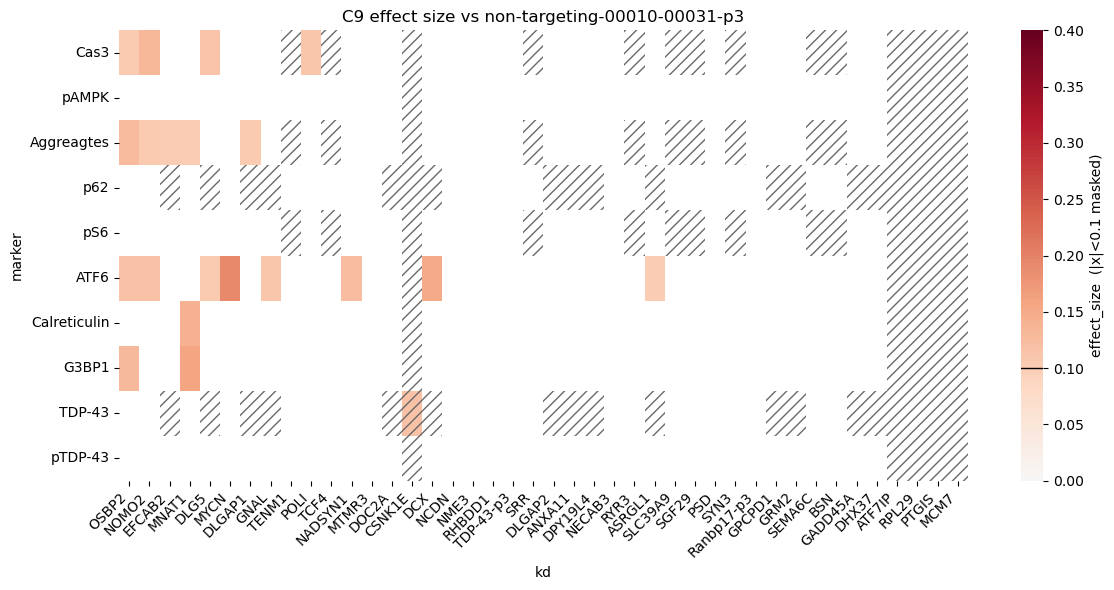


--- Control: non-targeting-00035-00050-p3 ---


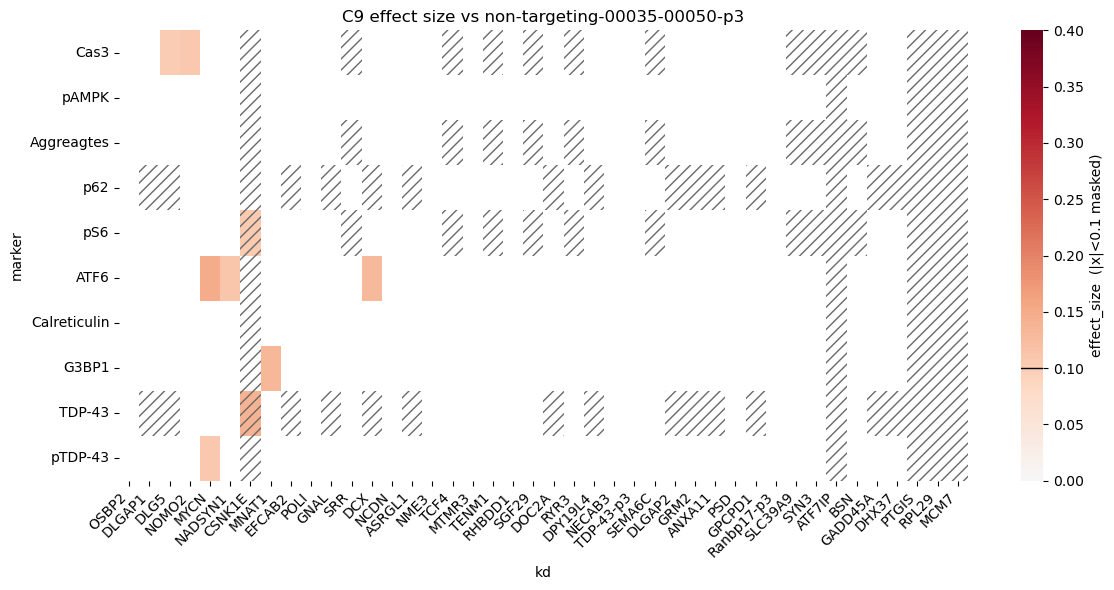


--- Control: non-targeting-00053-00059-p3 ---


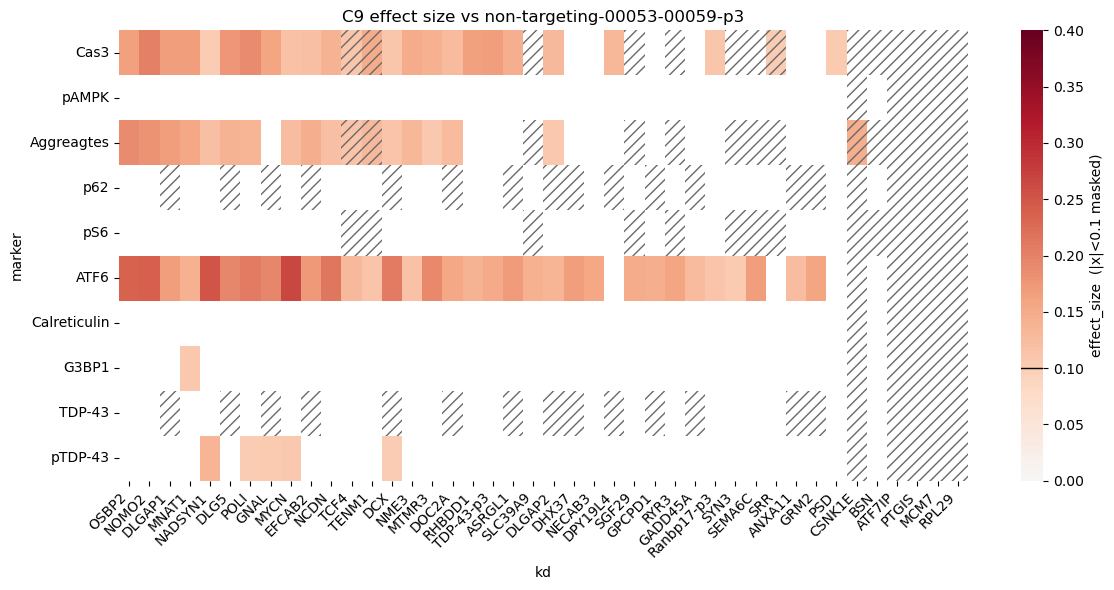


--- Control: non-targeting-00111-00121-p3 ---


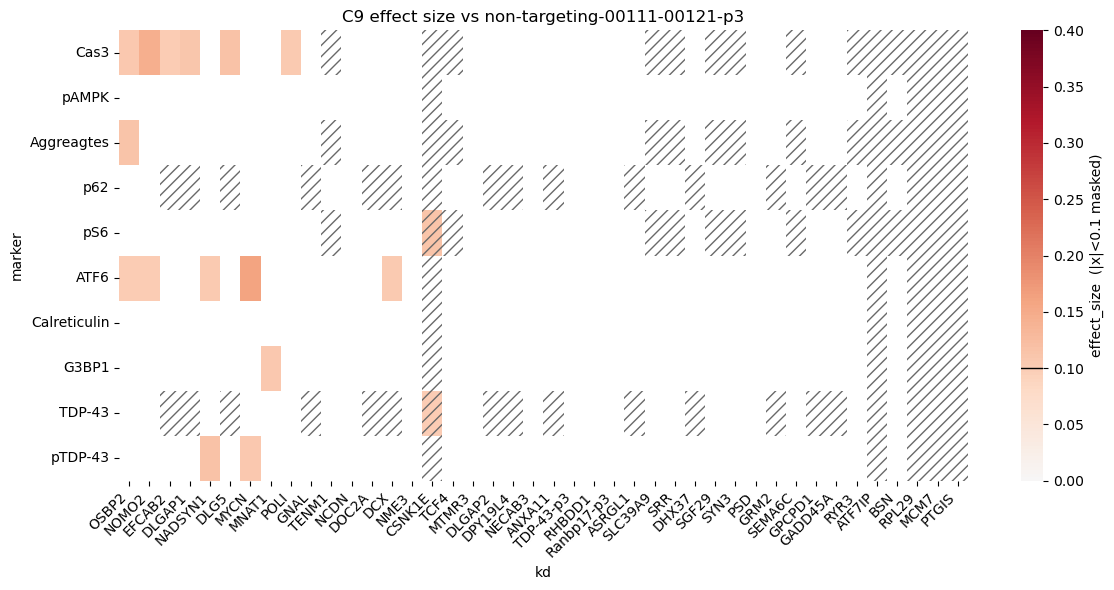

In [9]:
# Example: weighted effect size, marker × KD, per control.
# Mask |effect|<0.1, hatch outline-plate entries, drop "Empty" KDs (default of filter_data).
controls_available = sorted(data["control"].dropna().unique())

for c in controls_available:
    print(f"\n--- Control: {c} ---")
    subset = filter_data(
        data,
        batches=["weighted"],
        controls=[c],
        cell_lines=["C9"],
        exclude_markers=["DAPI"],
        clip_negative=True,
    )
    plot_heatmap(
        subset, x="kd", y="marker", value="effect_size",
        sort_cols_by="mean",
        mask_abs_below=0.1,
        grey_outline=True,
        title=f"C9 effect size vs {c}",
        save_as=f"heatmap_marker_by_kd_{c}.png",
    );

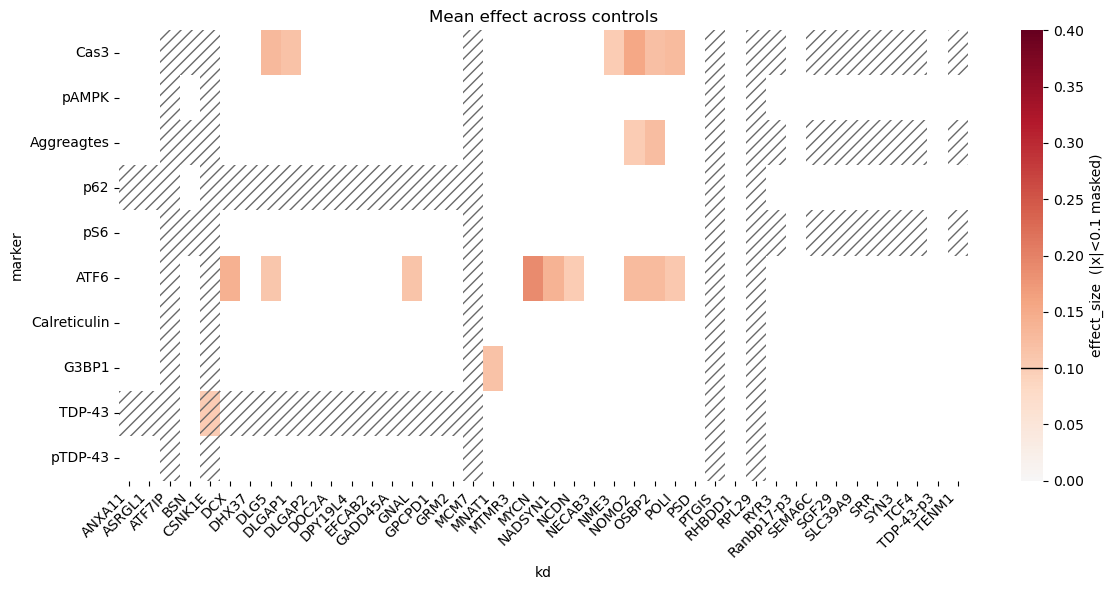

In [10]:
# Mean across all controls, per KD and marker:
subset = filter_data(
    data,
    batches=["batch1"],
    cell_lines=["C9"],
    exclude_markers=["DAPI"],
    clip_negative=True,
)
plot_heatmap(
    subset, x="kd", y="marker", value="effect_size",
    aggfunc="mean",
    mask_abs_below=0.1,
    grey_outline=True,
    title="Mean effect across controls",
    save_as=f"heatmap_marker_by_kd_avg_controls.png",
);

## 5. Flexible scatter / strip plot

Pick any columns for `x`, `y`, `hue` and (optionally) `style` / `size`.

In [11]:
def plot_scatter(
    df: pd.DataFrame,
    x: str = "effect_size",
    y: str = "kd",
    hue: Optional[str] = "batch",
    style: Optional[str] = None,
    size: Optional[str] = None,
    sort_y_by_value: bool = True,
    invert_y: bool = True,
    figsize=(10, 8),
    palette="tab10",
    s: int = 70,
    title: Optional[str] = None,
    vline_zero: bool = True,
    vline_threshold: Optional[float] = None,
    xlim: Optional[tuple] = None,
    grey_outline: bool = False,   # mark on_plate_outline=True entries with a grey ring
    save_as: Optional[str] = None,
):
    if df.empty:
        print("No data to plot."); return None
    plot_df = df.copy()
    if sort_y_by_value:
        order = plot_df.groupby(y)[x].mean().sort_values(ascending=False).index.tolist()
        plot_df[y] = pd.Categorical(plot_df[y], categories=order, ordered=True)

    fig, ax = plt.subplots(figsize=figsize)

    # All points keep their hue colour
    sns.scatterplot(
        data=plot_df, x=x, y=y,
        hue=hue, style=style, size=size,
        palette=palette, s=s, alpha=0.8, ax=ax,
    )

    # Outline halo: an empty grey ring drawn slightly larger than the marker
    if grey_outline and "on_plate_outline" in plot_df.columns:
        outline_df = plot_df[plot_df["on_plate_outline"].fillna(False).astype(bool)]
        if not outline_df.empty:
            ax.scatter(
                outline_df[x], outline_df[y],
                facecolors="none", edgecolors="dimgrey",
                s=s * 2.0, linewidths=1.8,
                zorder=3, label="on plate outline",
            )

    if vline_zero:
        ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    if invert_y:
        ax.invert_yaxis()
    if hue is not None or grey_outline:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    if vline_threshold is not None:
        ax.axvline(vline_threshold, color="red", linestyle="--", linewidth=1, alpha=0.7)
        # Highlight y-categories that exceed the threshold (ignoring outline points)
        score_df = plot_df
        # if grey_outline and "on_plate_outline" in plot_df.columns:
        #     score_df = plot_df.loc[~plot_df["on_plate_outline"].fillna(False).astype(bool)]
        exceed = score_df.loc[score_df[x] >= vline_threshold, y].unique()
        for tick in ax.get_yticklabels():
            if tick.get_text() in exceed:
                tick.set_color("red")

    if xlim is not None:
        ax.set_xlim(xlim)
    ax.set_title(title or f"{x} vs {y}" + (f" coloured by {hue}" if hue else ""))
    plt.tight_layout()
    if save_as:
        fig.savefig(os.path.join(PLOTS_DIR, save_as), dpi=200, bbox_inches="tight")
    plt.show()
    return fig, ax

## plot all KDs effect per Marker, grouped per control

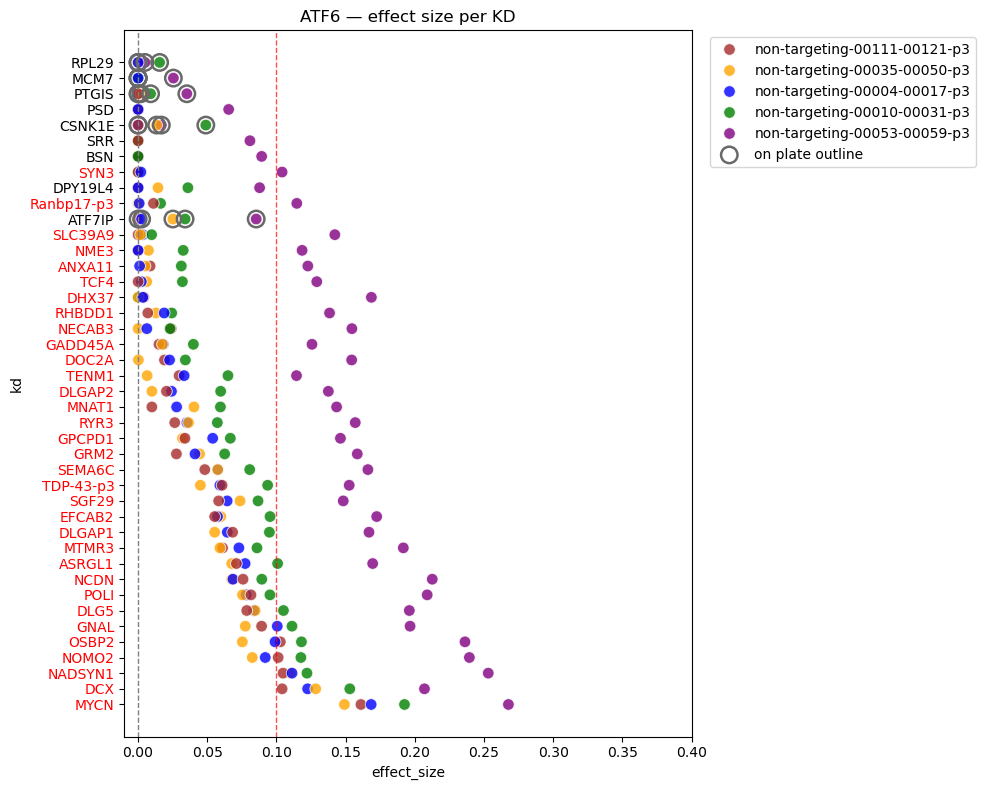

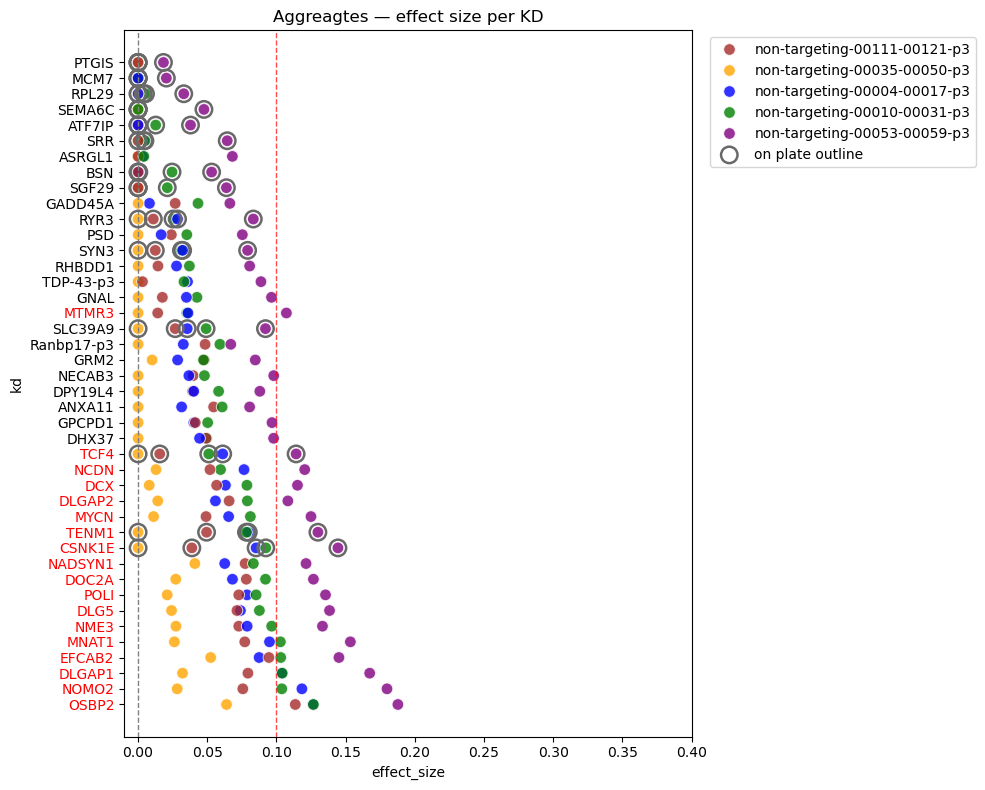

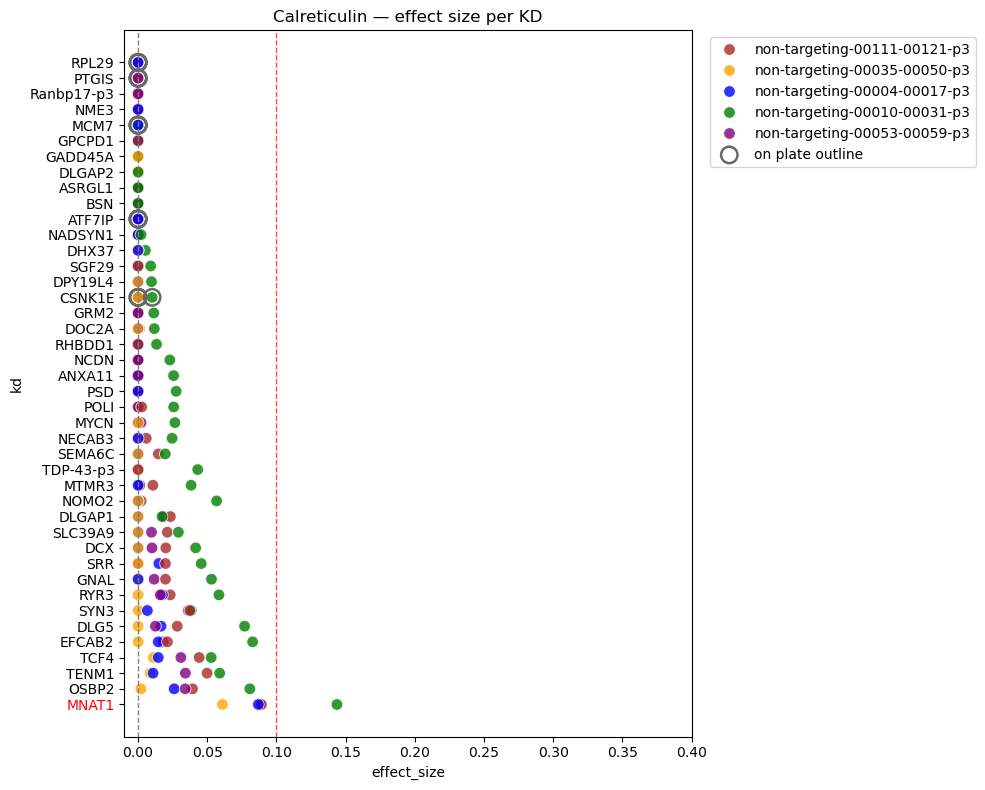

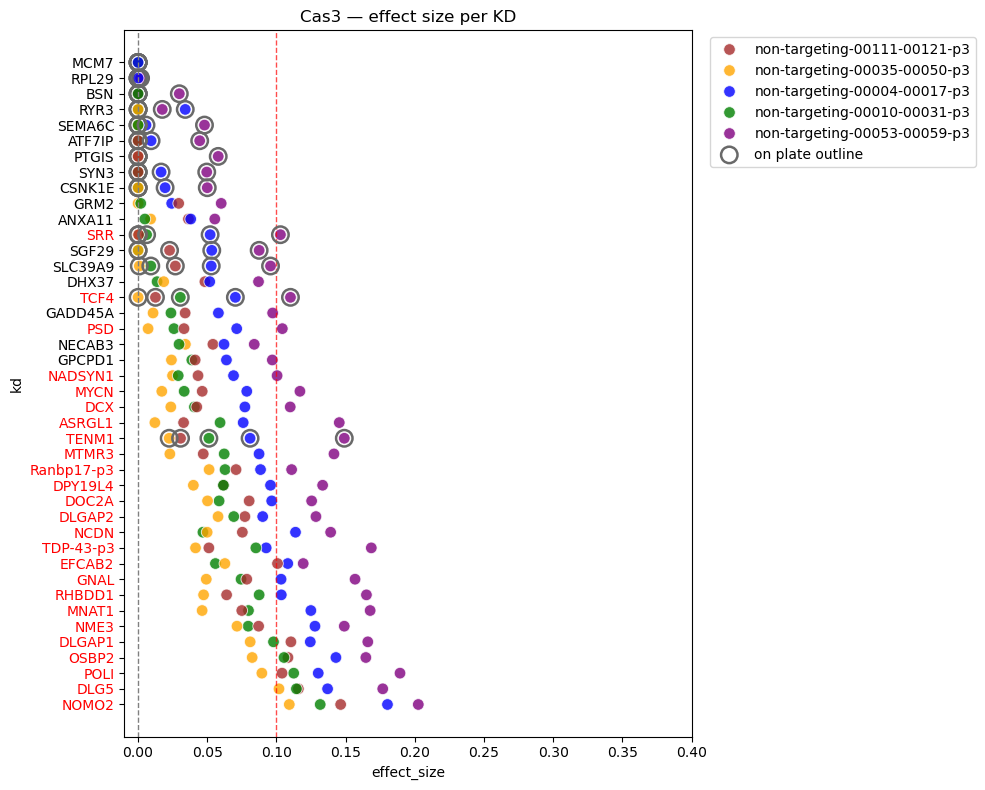

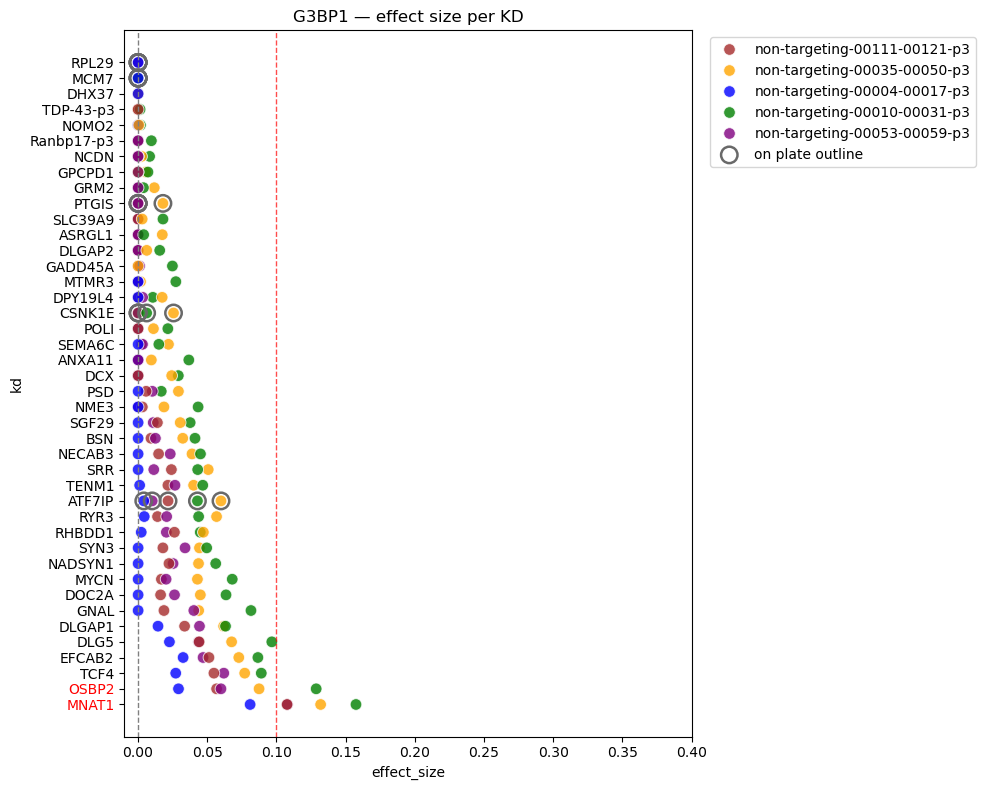

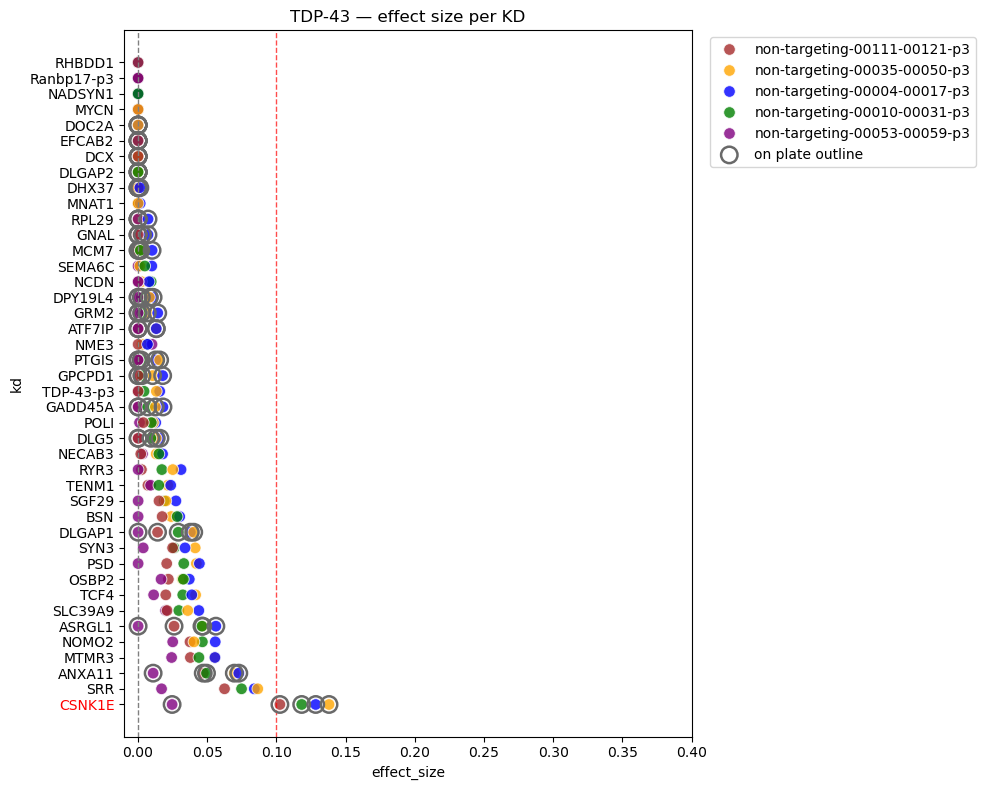

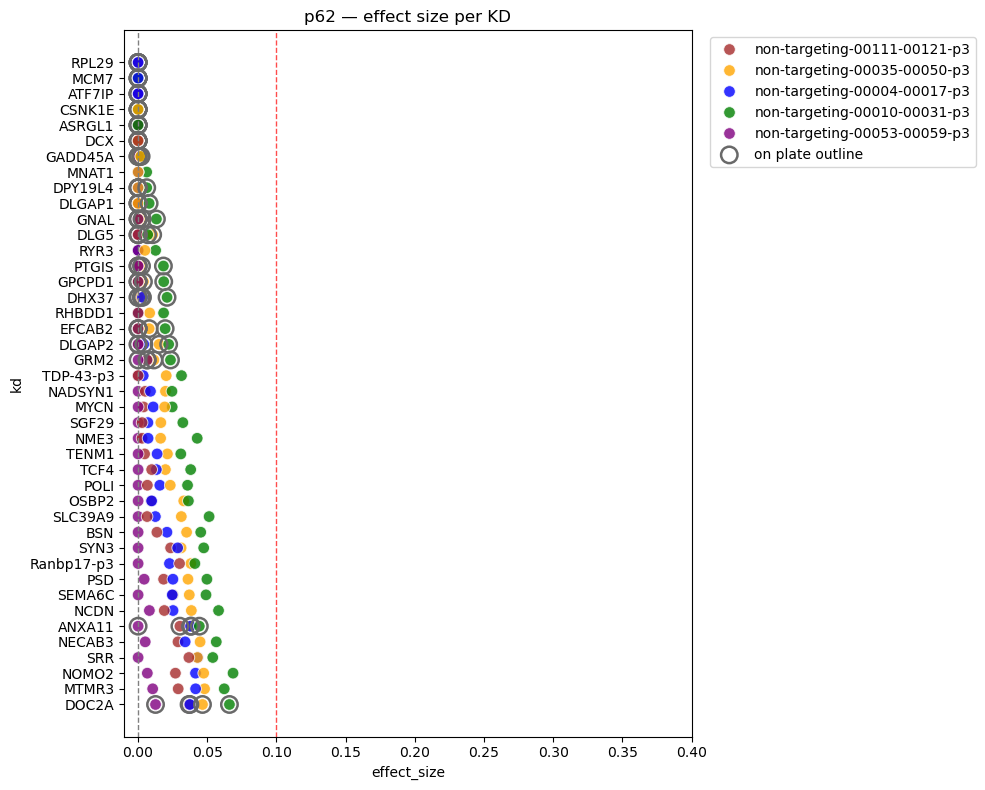

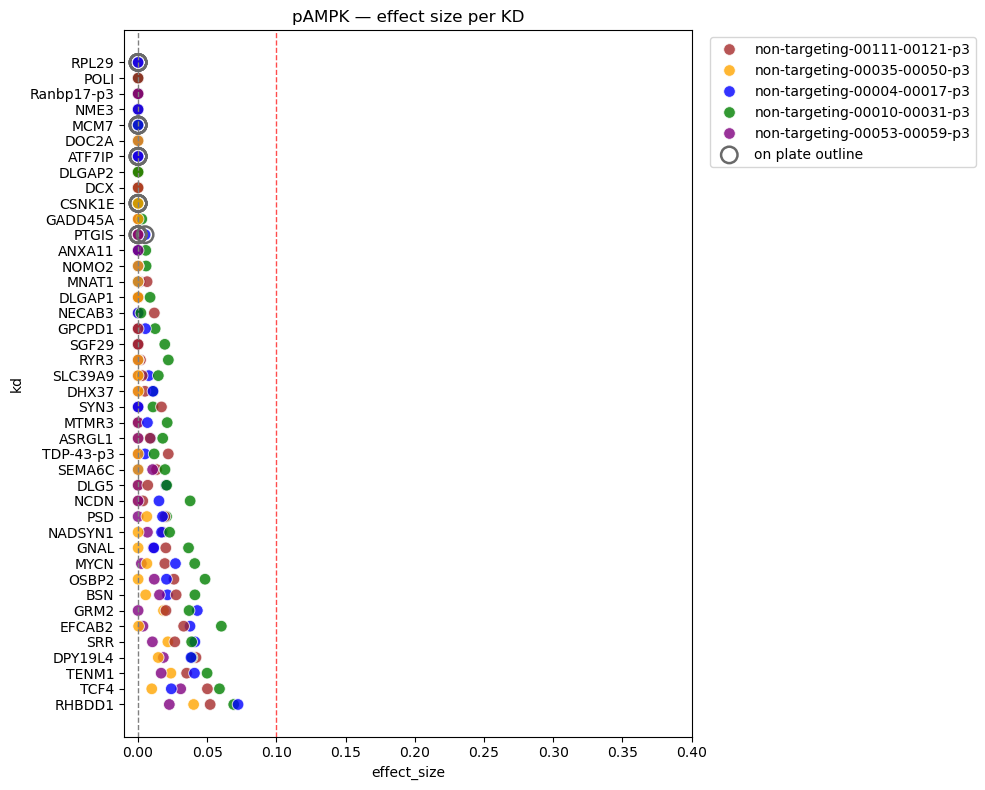

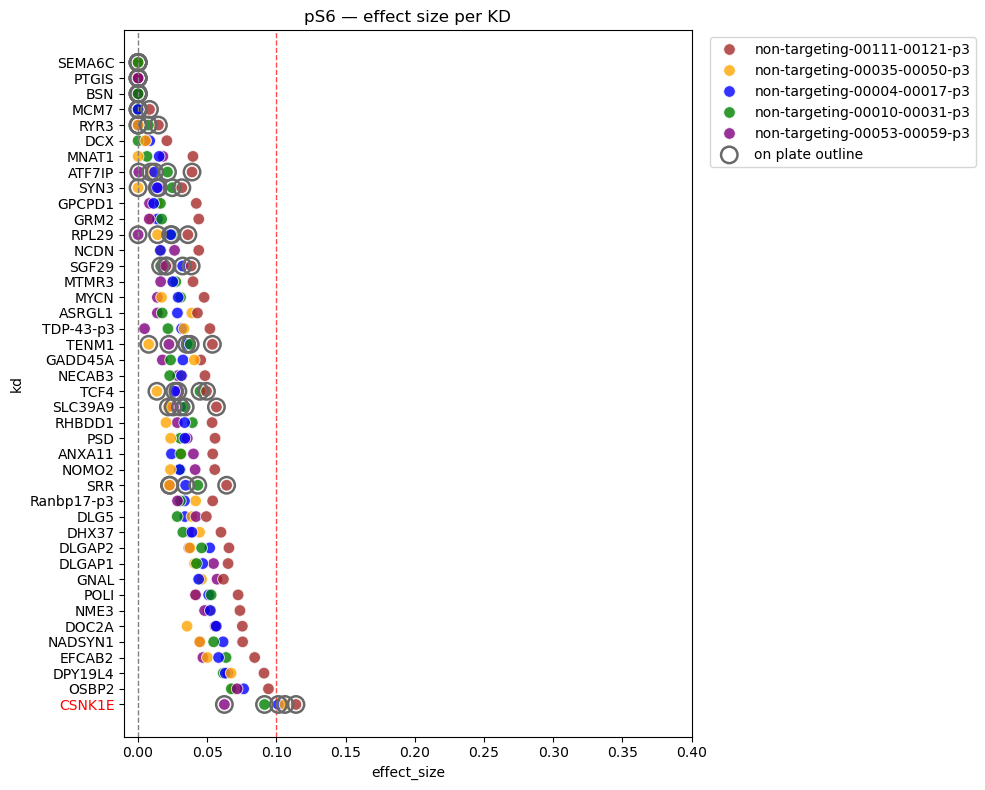

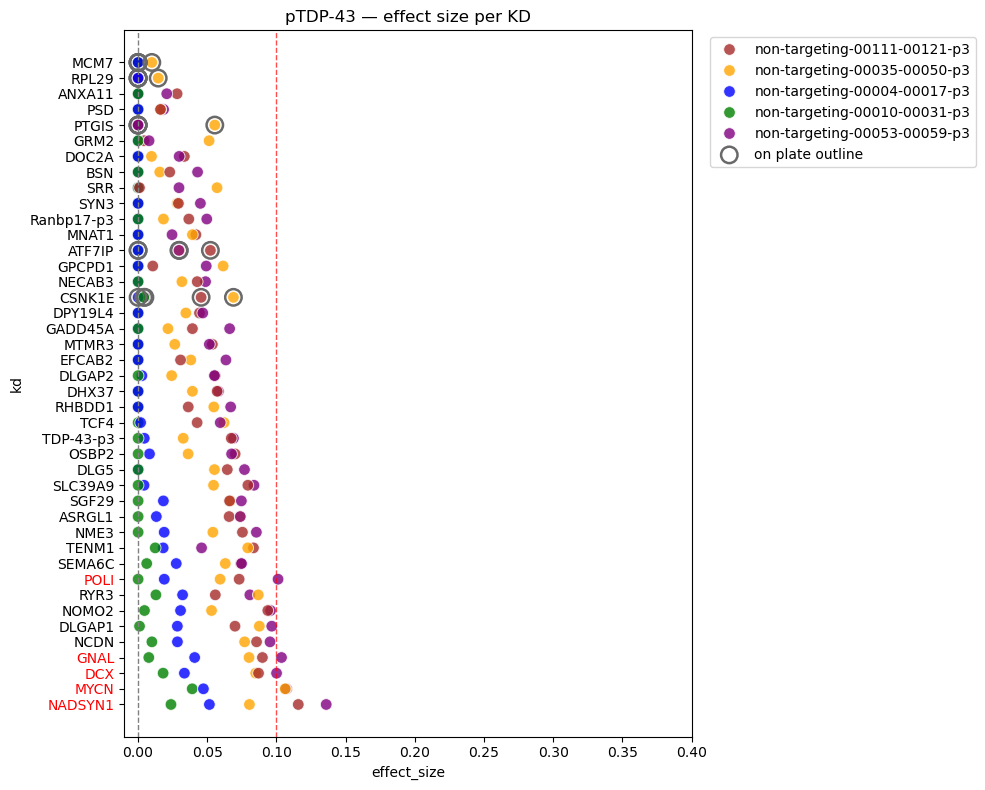

In [12]:
# per marker scatter of effect size vs KD, coloured by control.
# Outline-plate KDs are drawn in grey (X marker).
dir_name = "per_marker_scatter"

os.makedirs(os.path.join(PLOTS_DIR, dir_name), exist_ok=True)
for marker in sorted(data["marker"].unique()):
    subset = filter_data(
        data,
        markers=[marker],
        cell_lines=["C9"],
        batches=["batch1"],
        controls=None,
        clip_negative=True,
    )
    plot_scatter(
        subset, x="effect_size", y="kd", hue="control",
        title=f"{marker} — effect size per KD",
        save_as=f"per_marker_scatter/scatter_{marker}_all_controls_grey_outline.png",
        palette=CONTROL_COLORS,
        vline_threshold=0.1,
        xlim=(-0.01, 0.4),
        grey_outline=True,
    );

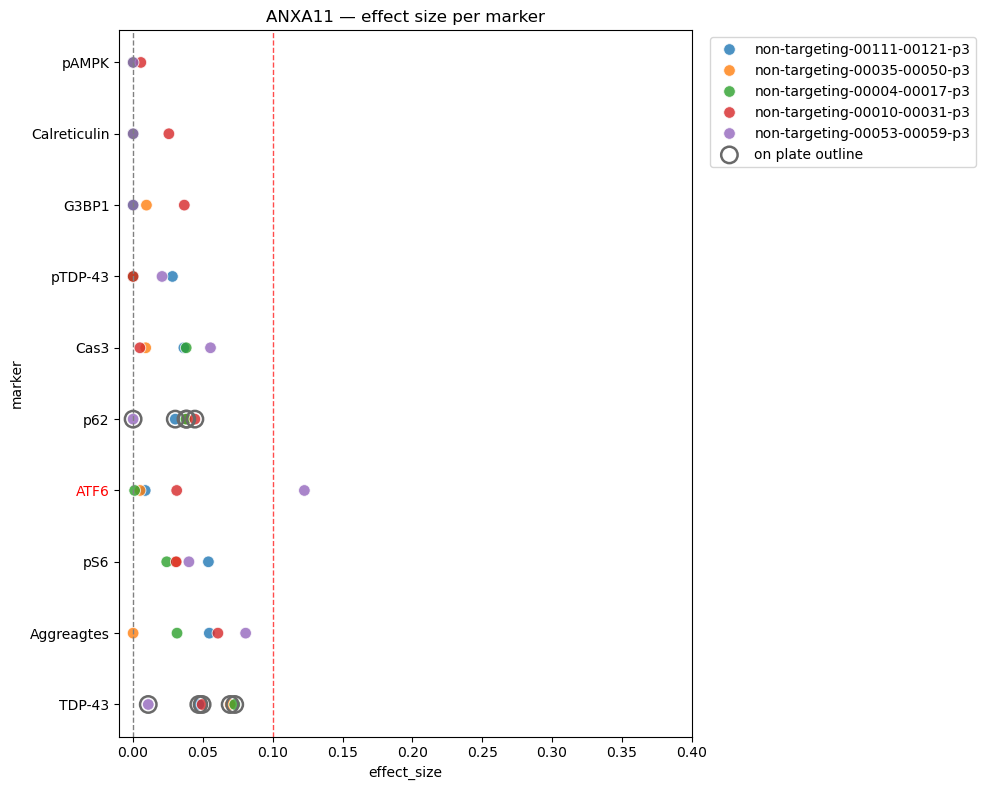

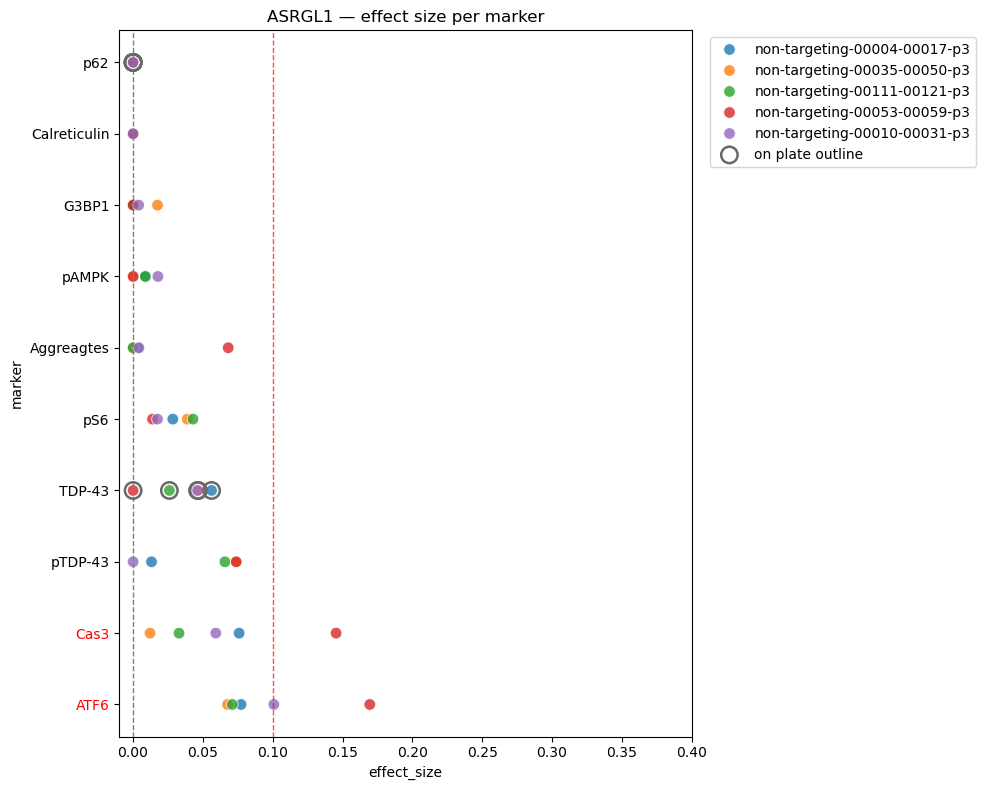

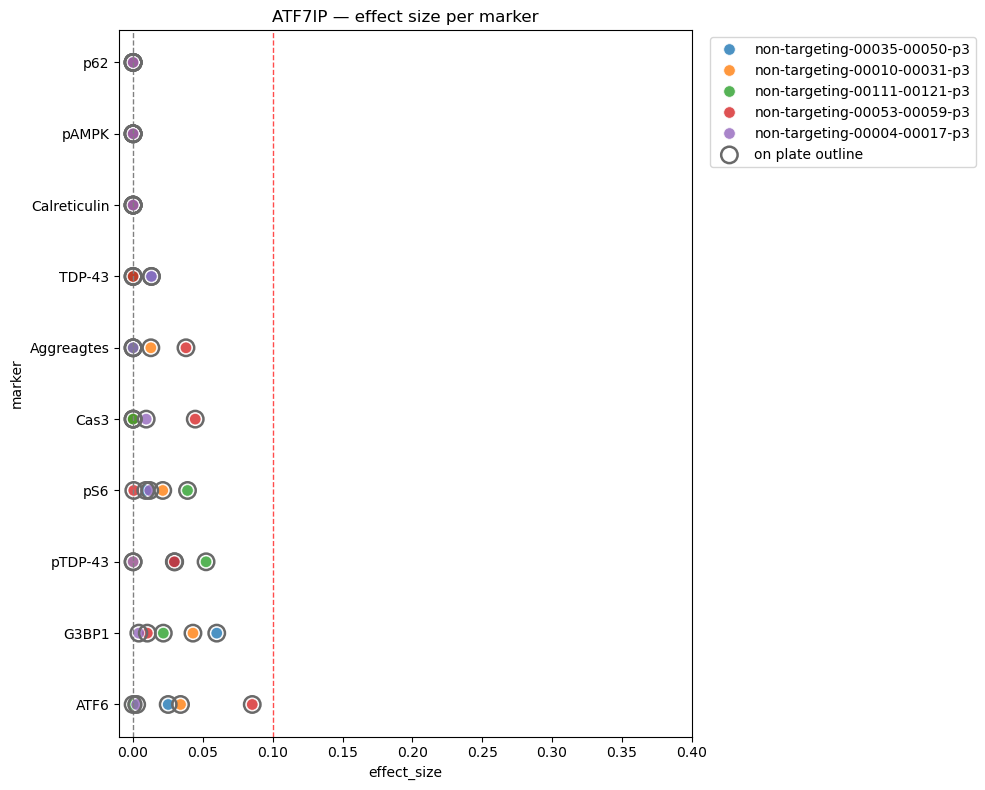

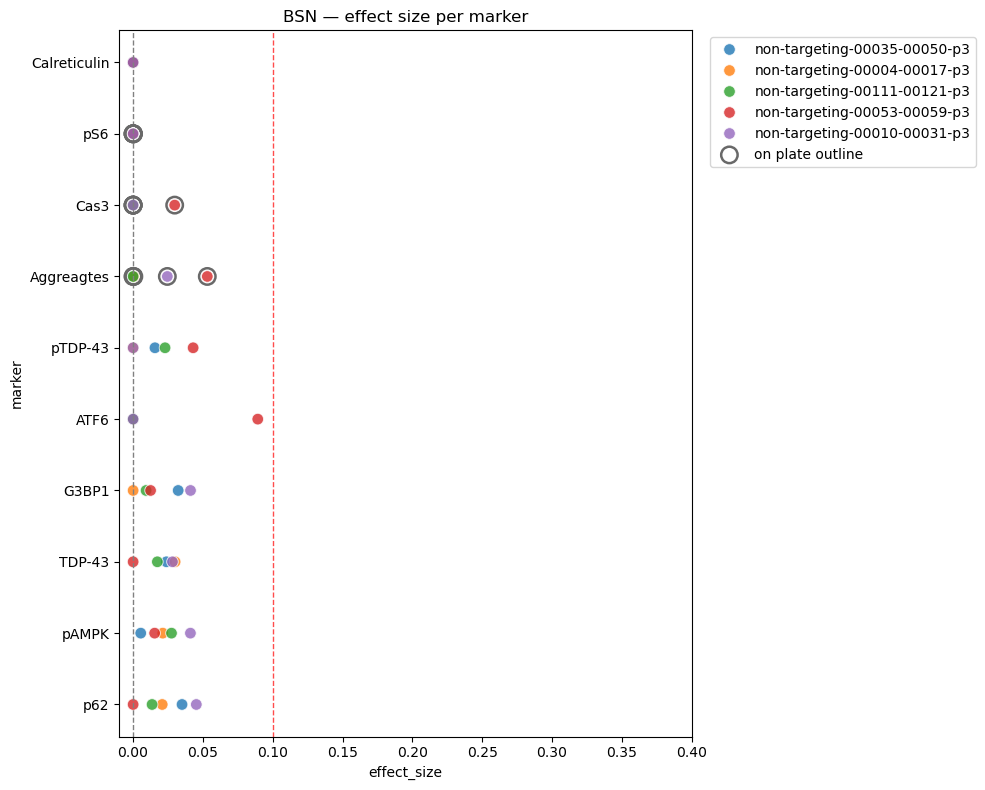

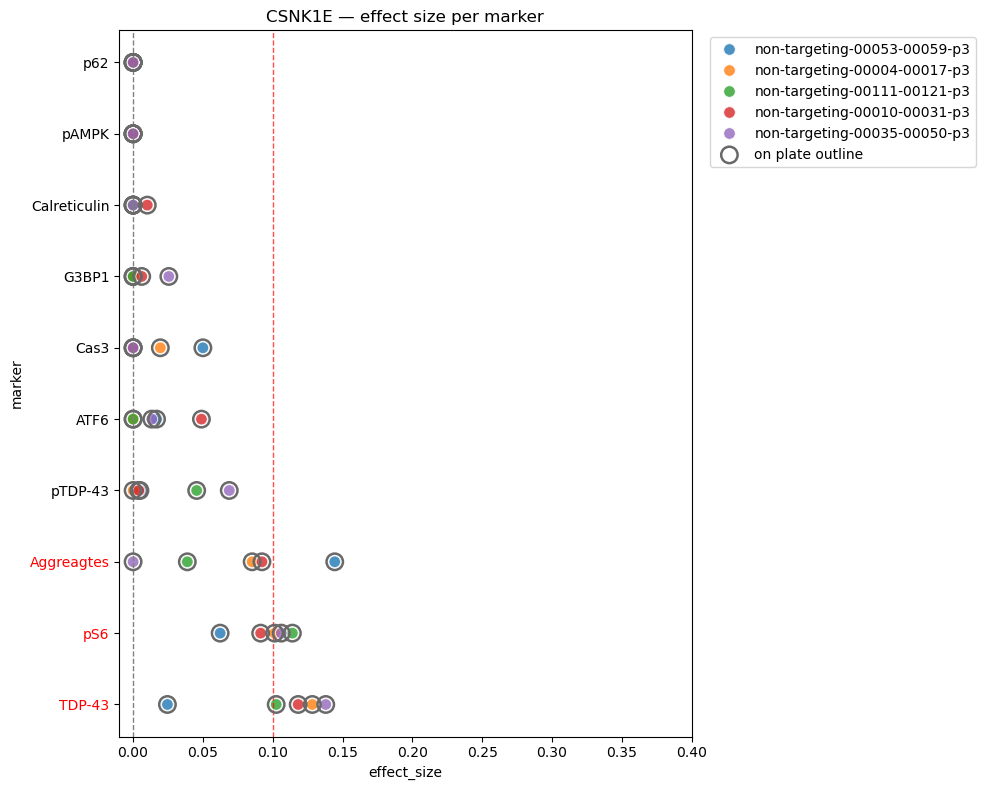

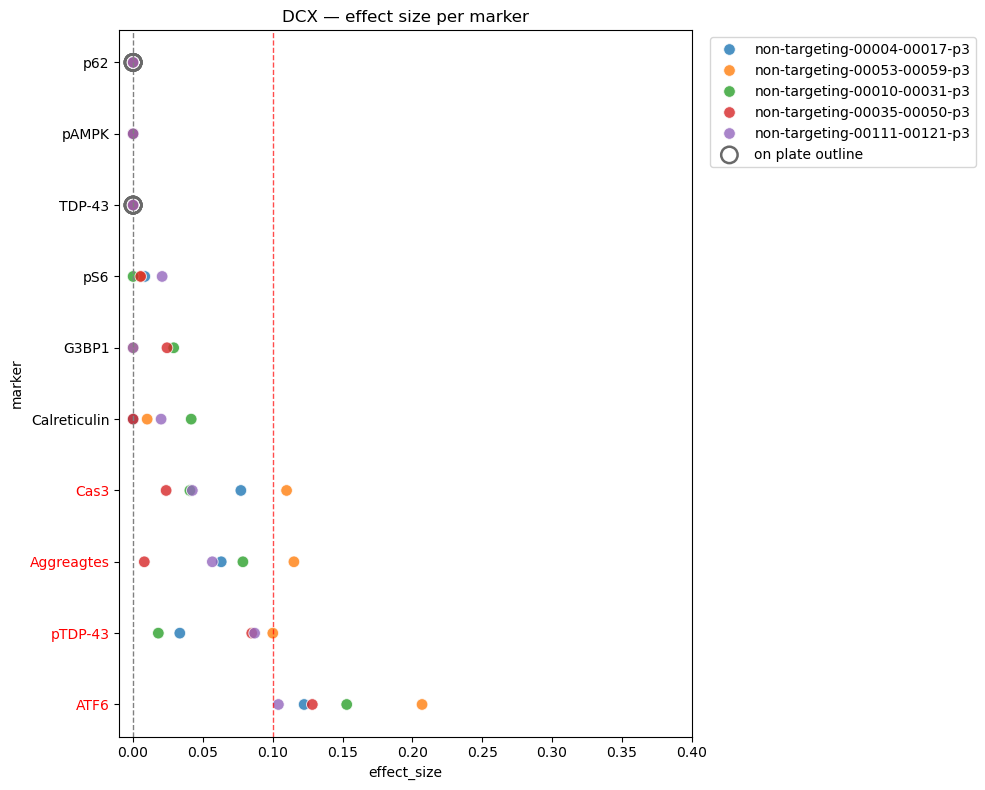

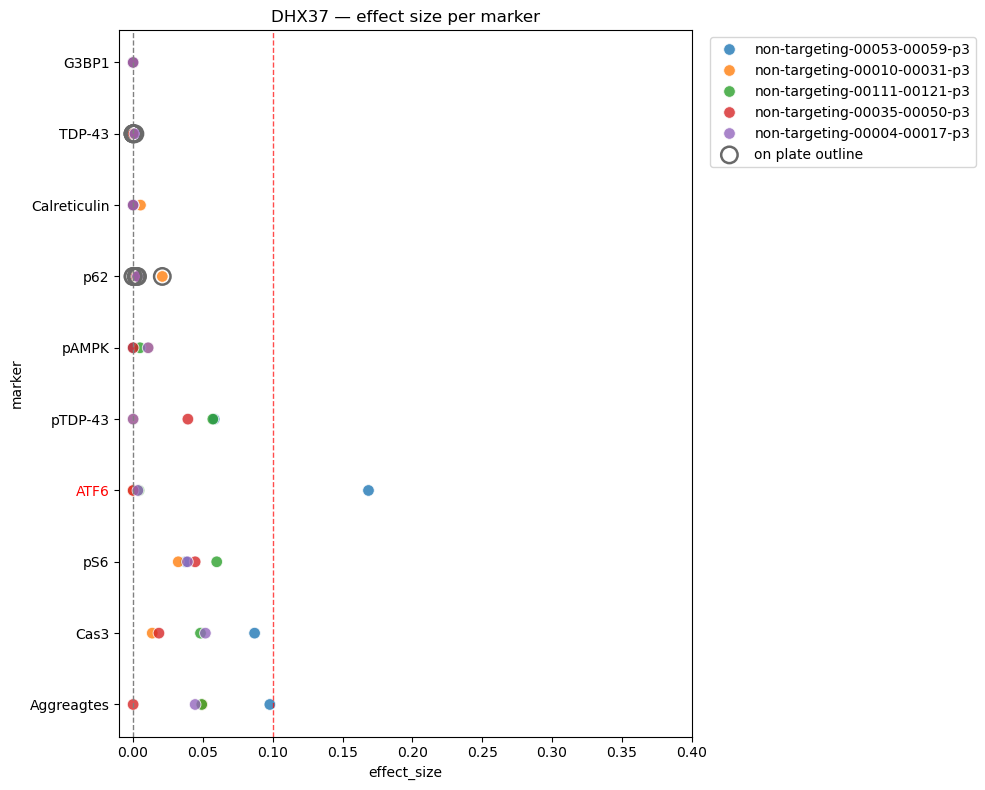

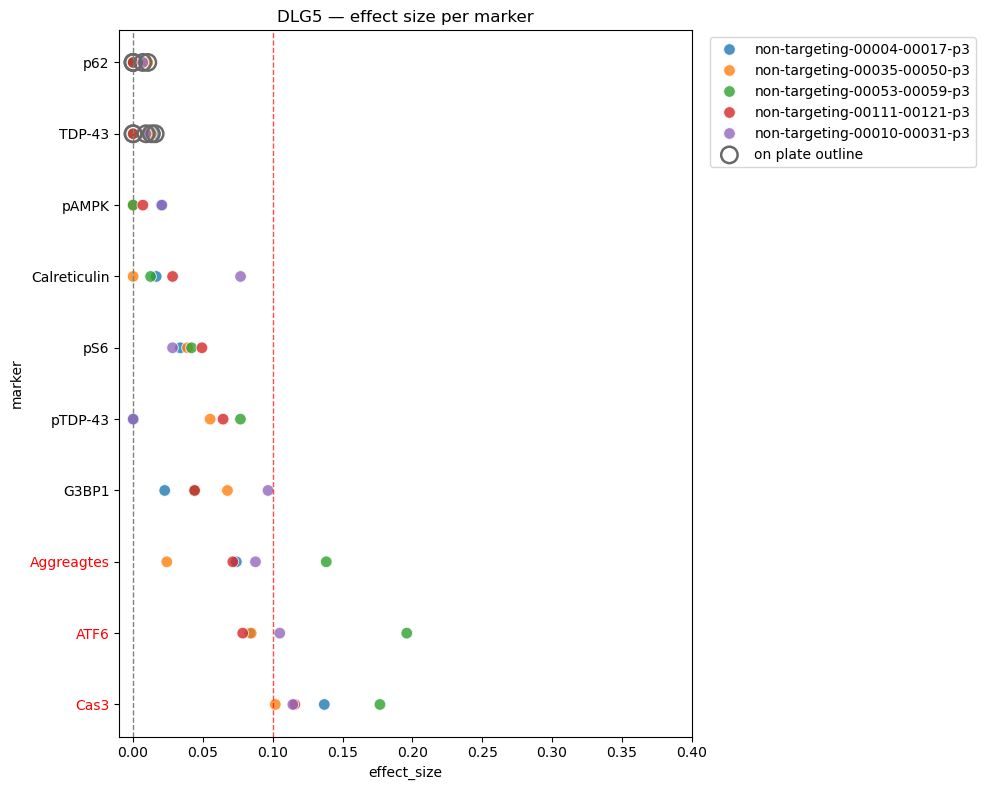

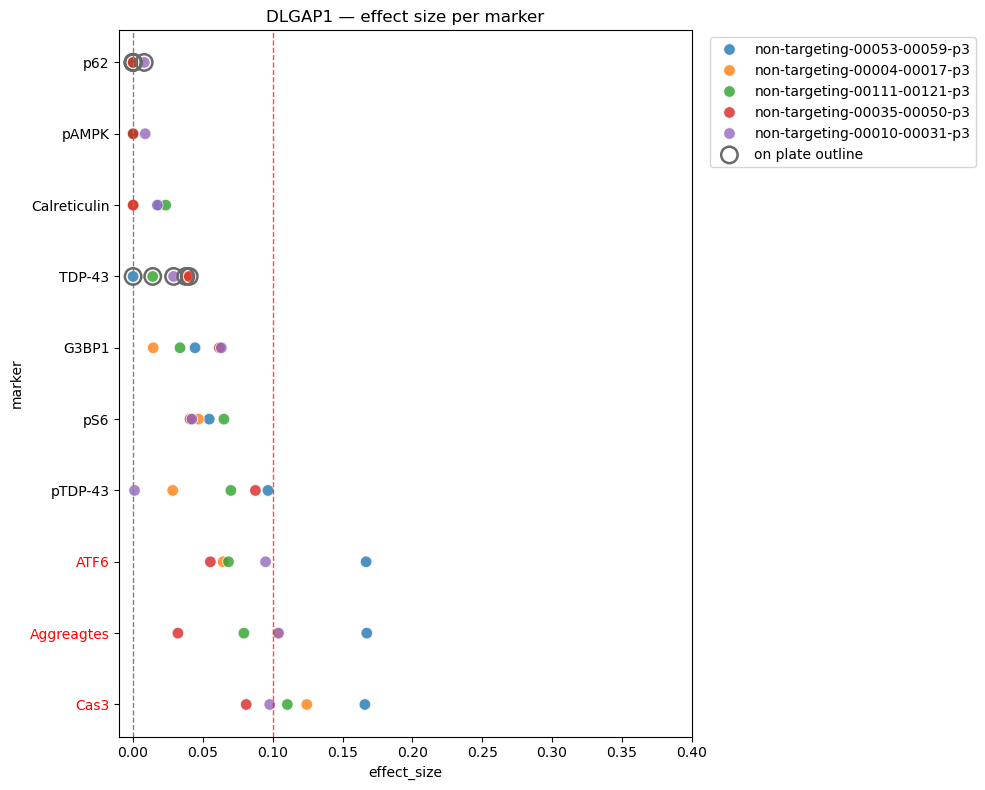

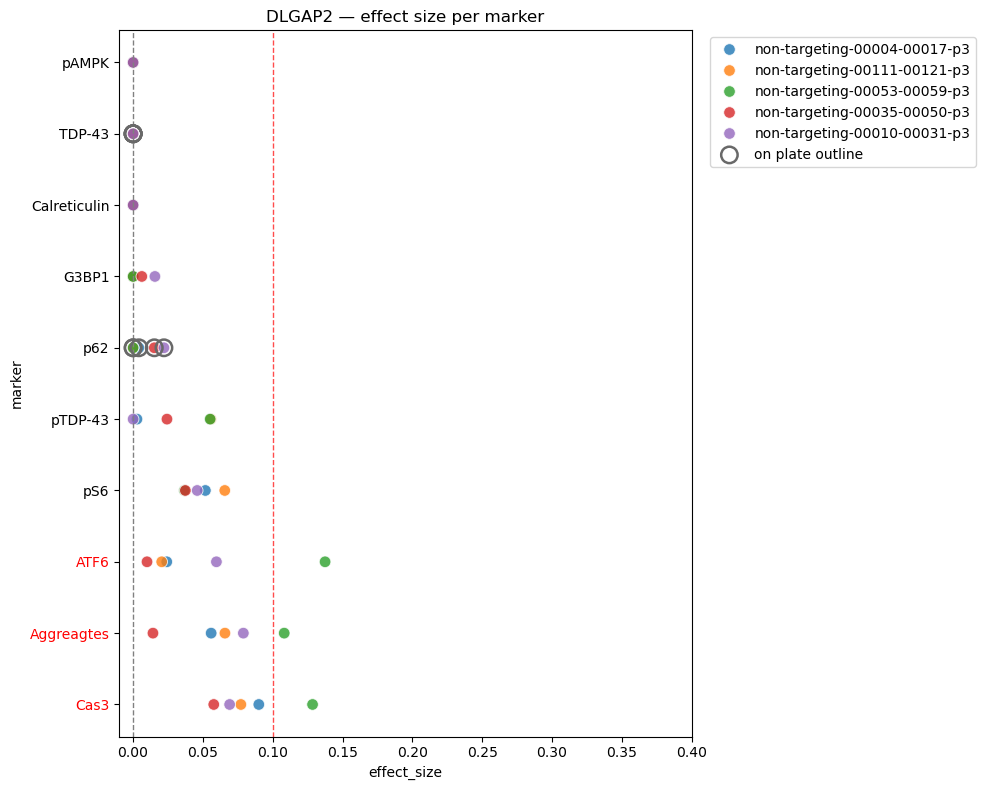

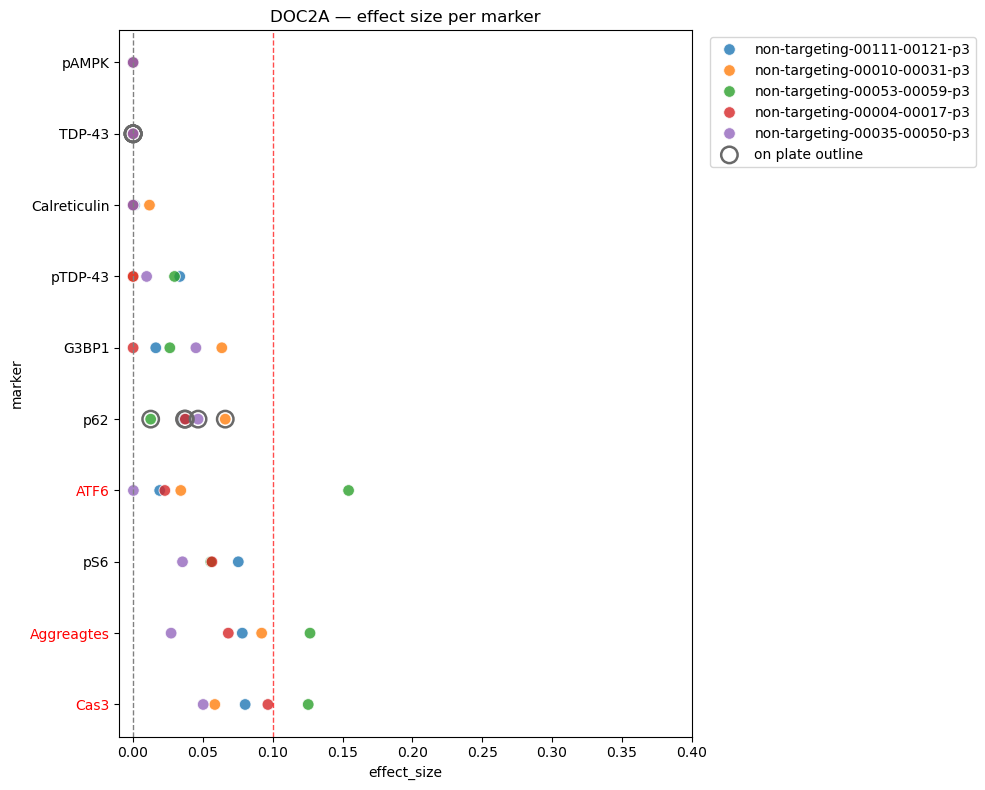

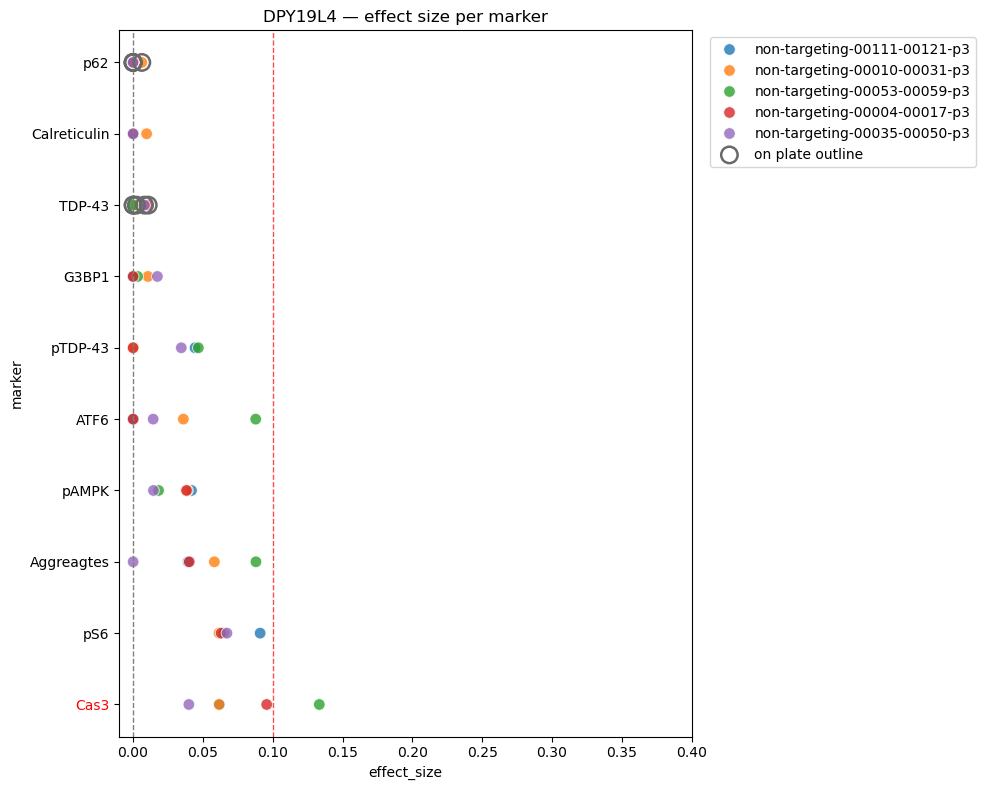

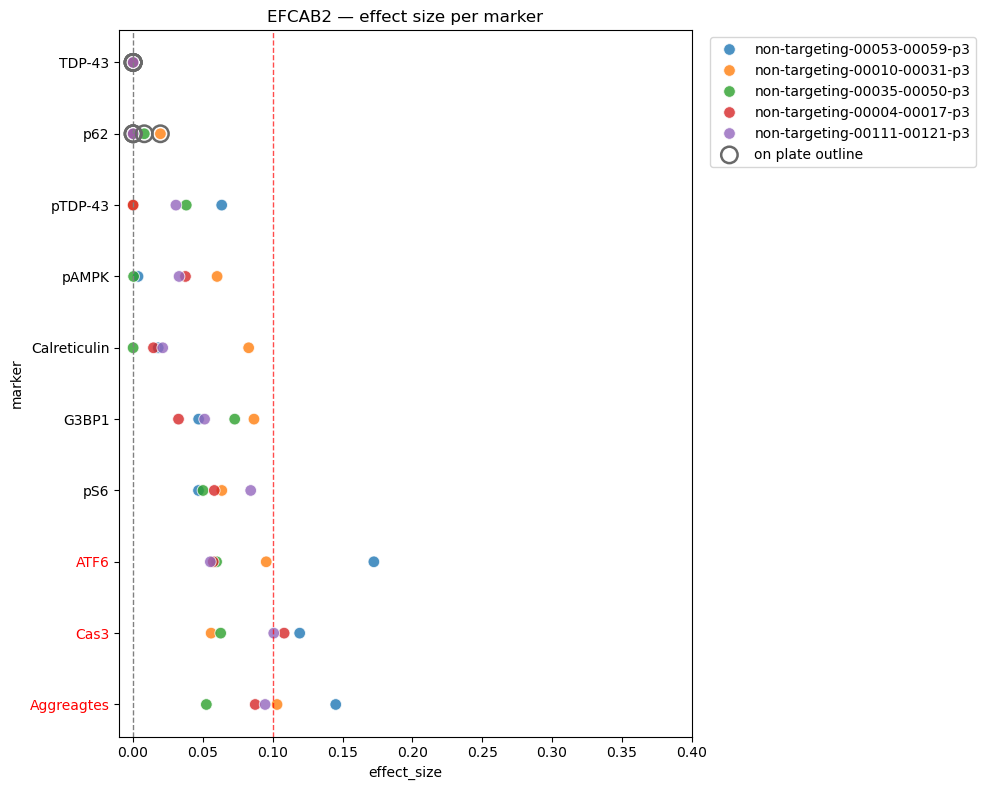

No data to plot.


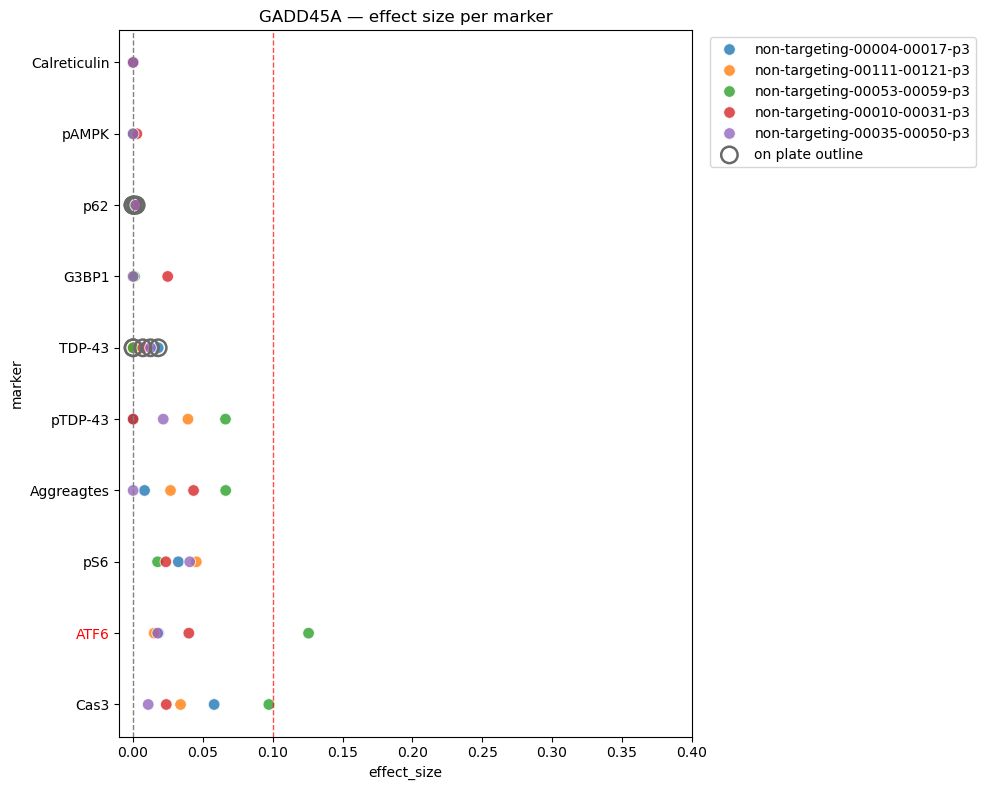

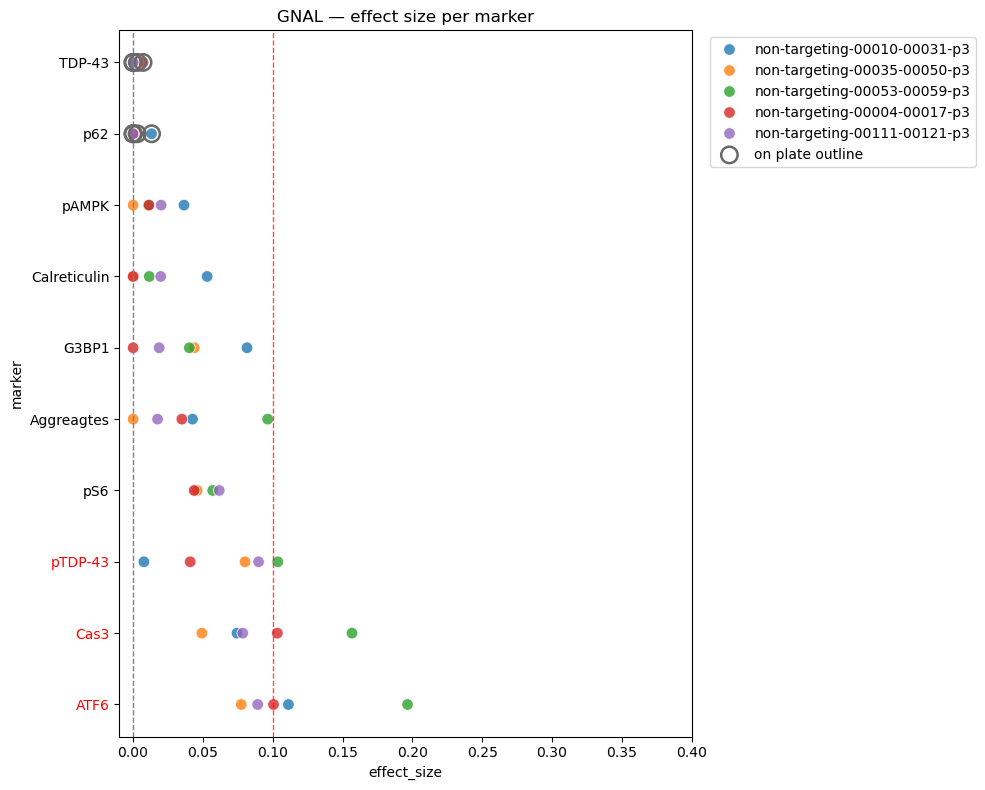

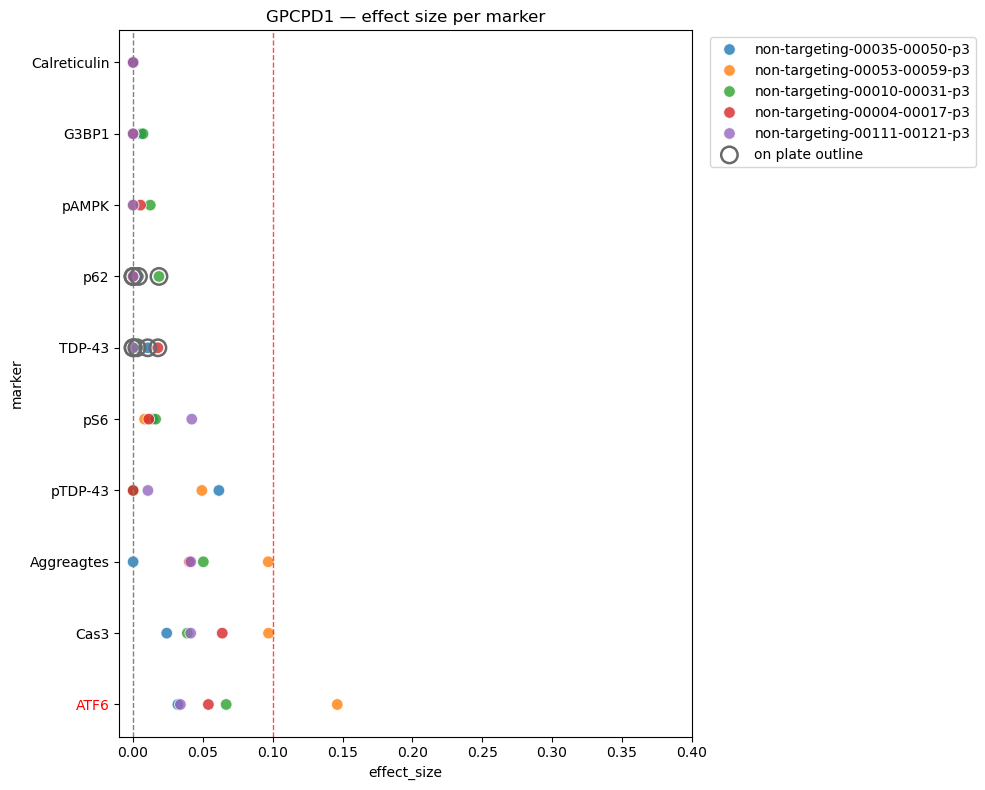

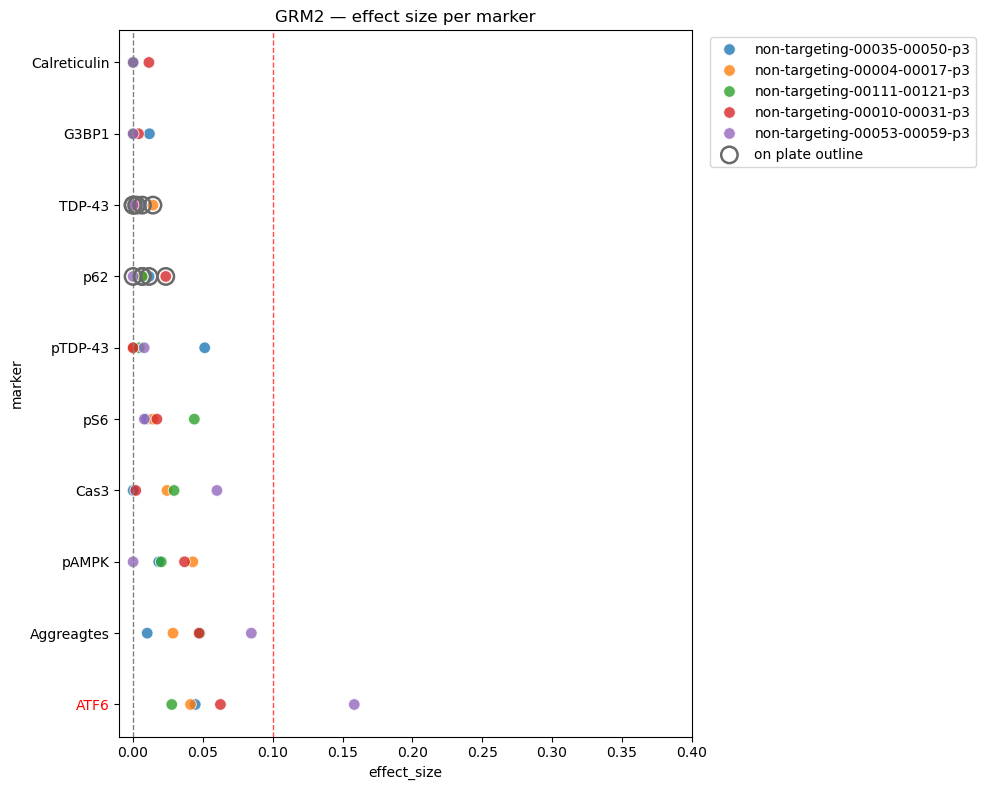

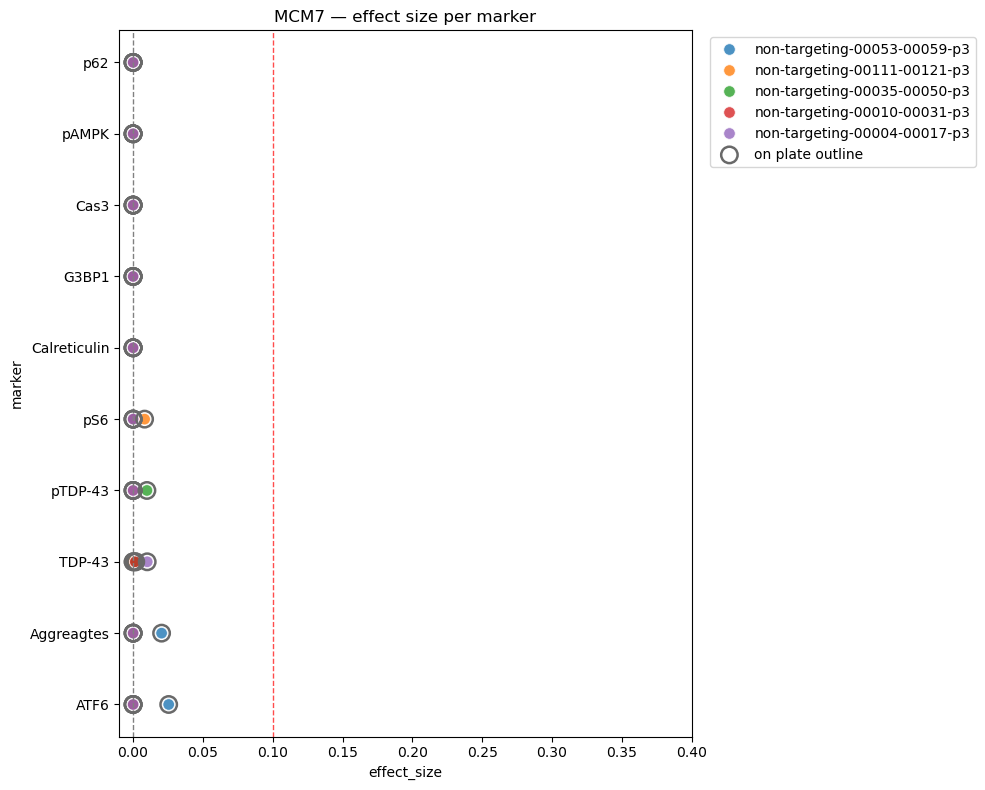

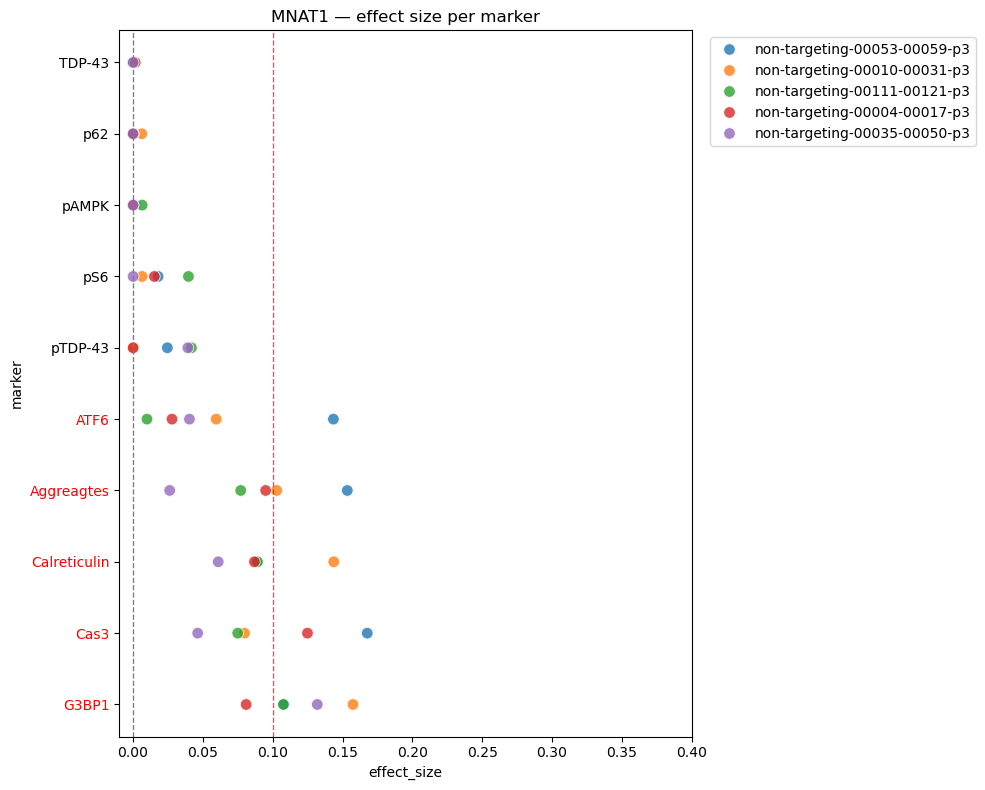

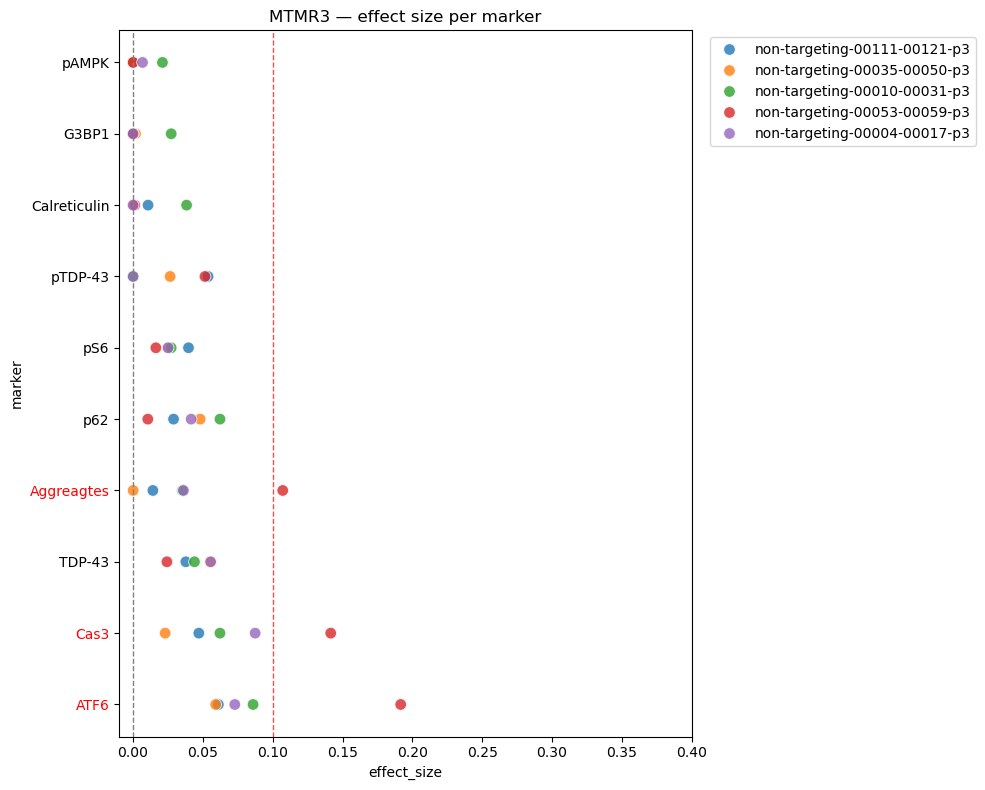

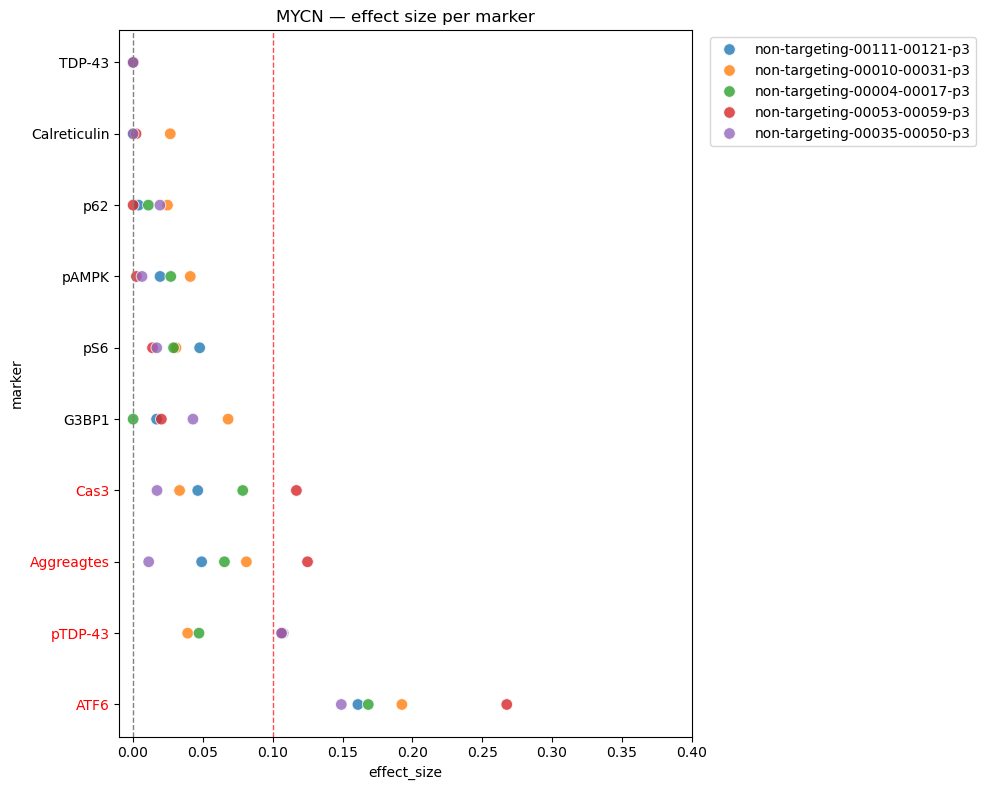

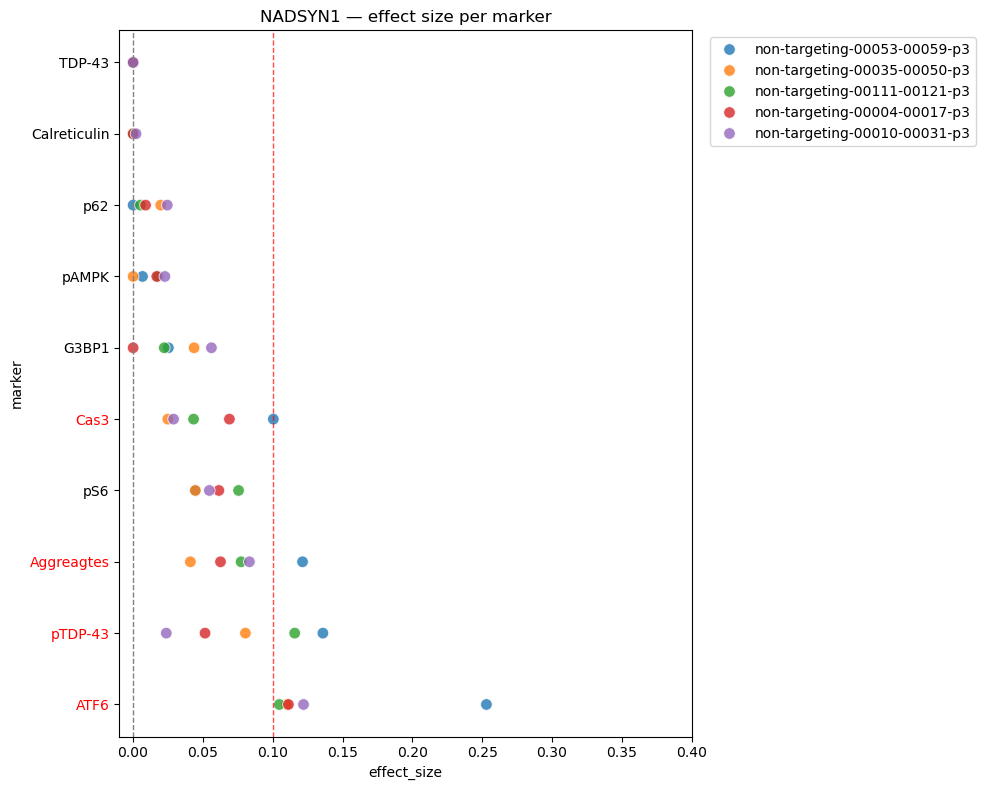

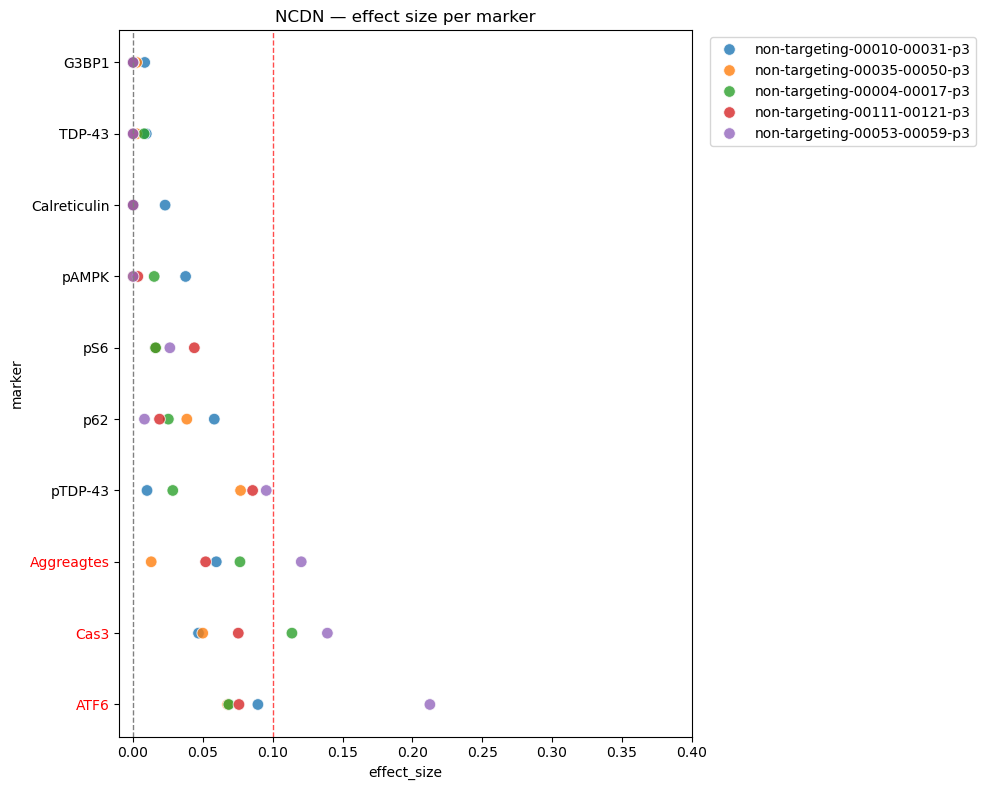

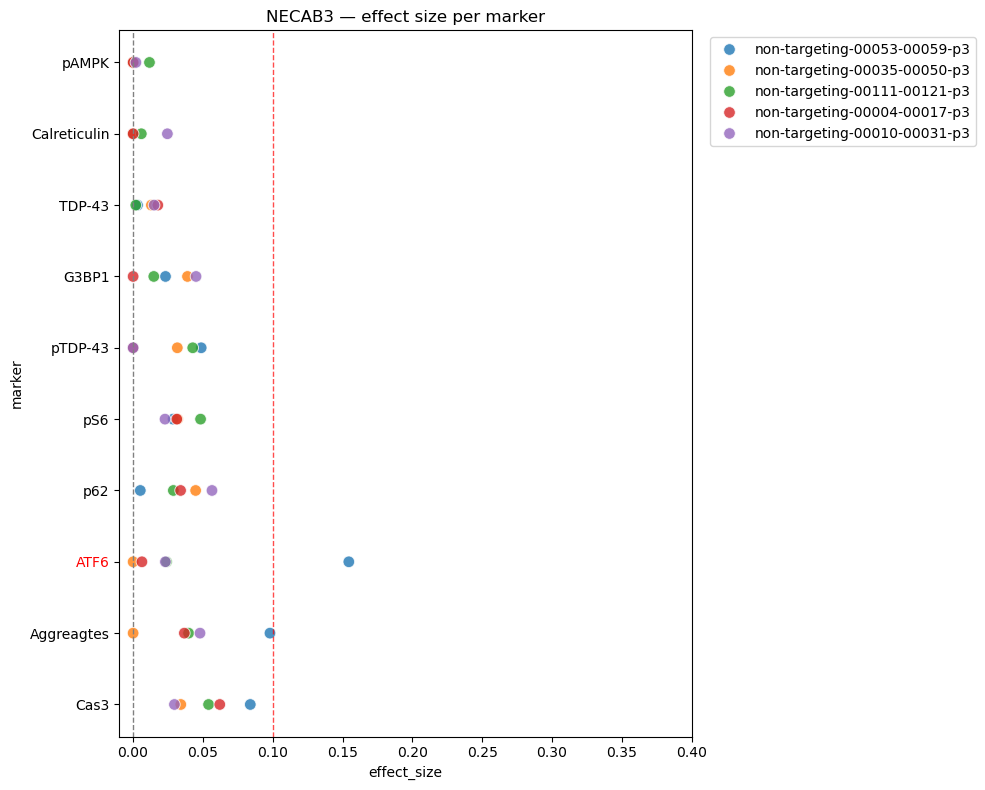

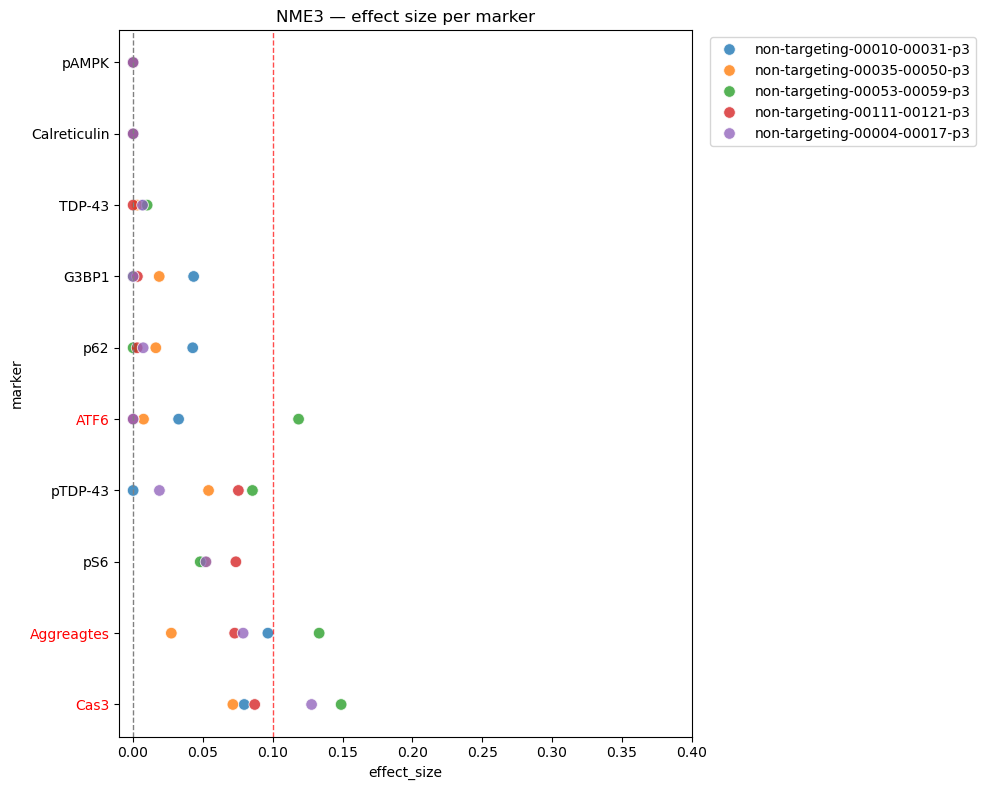

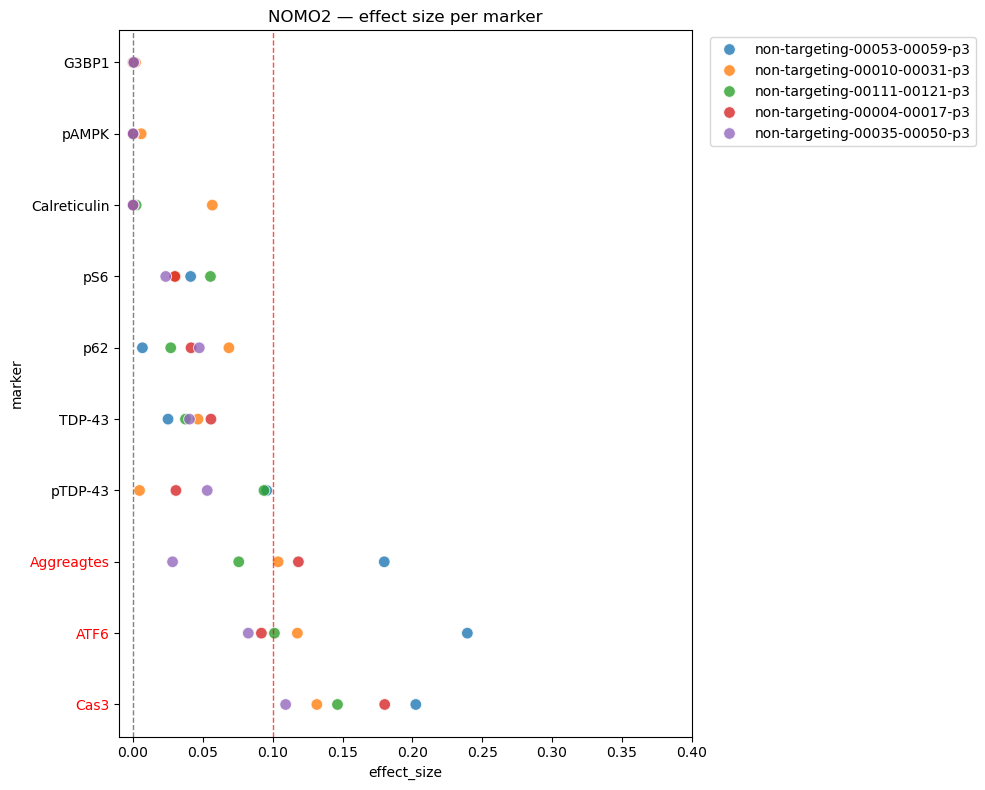

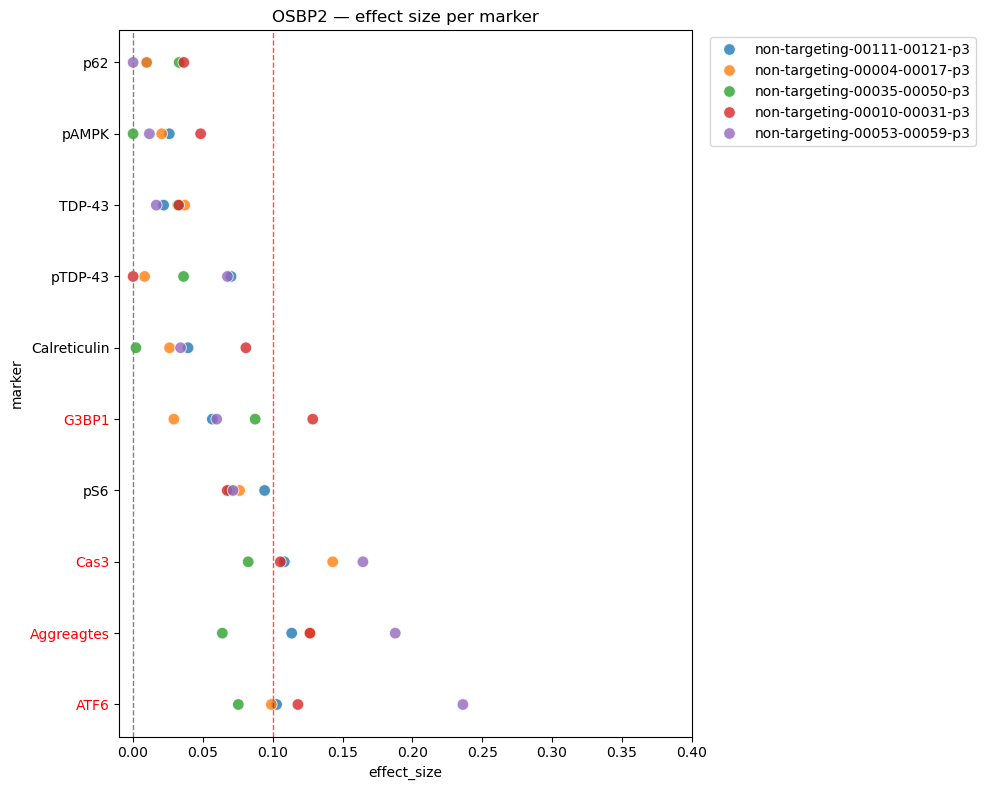

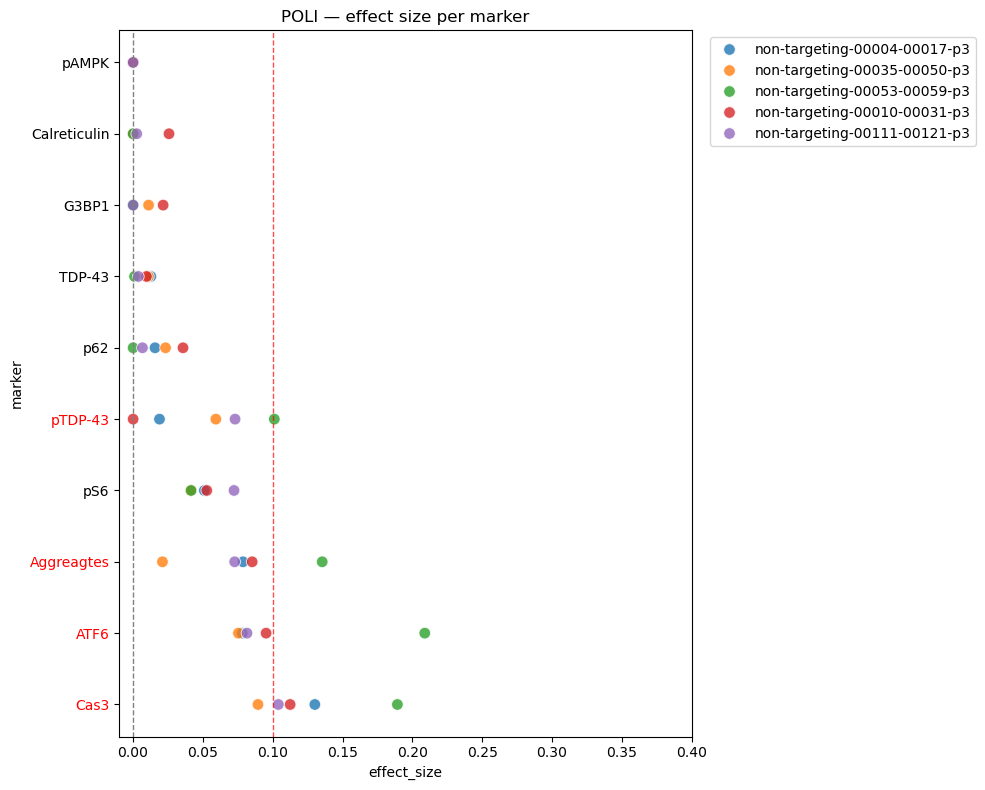

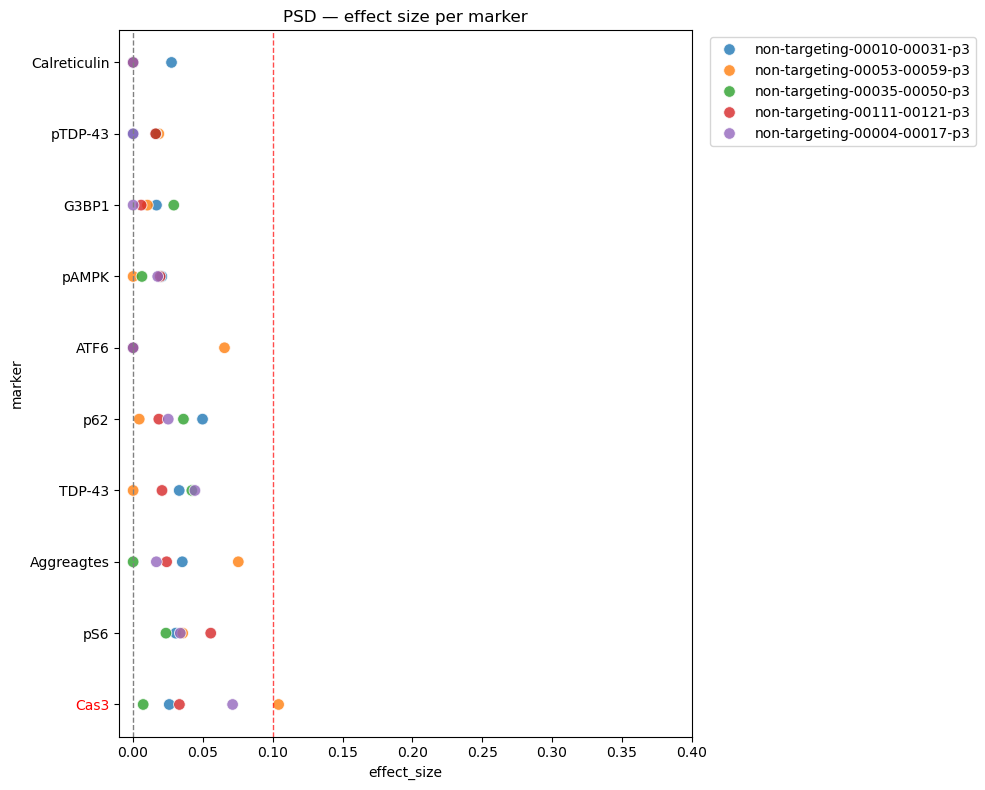

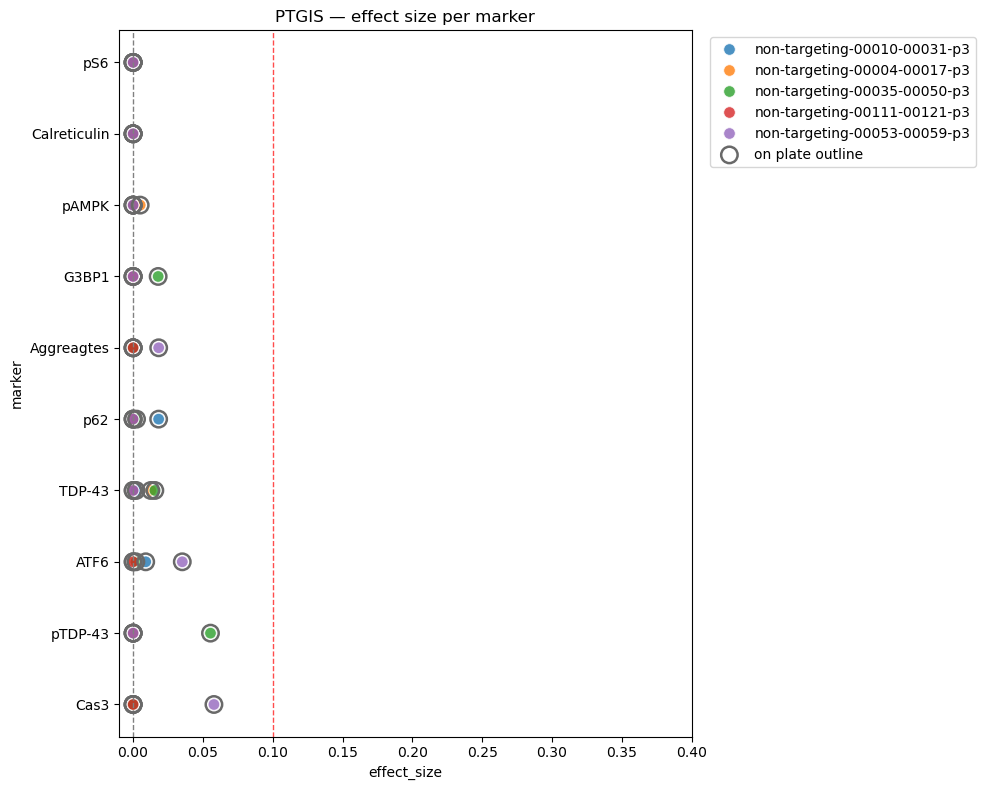

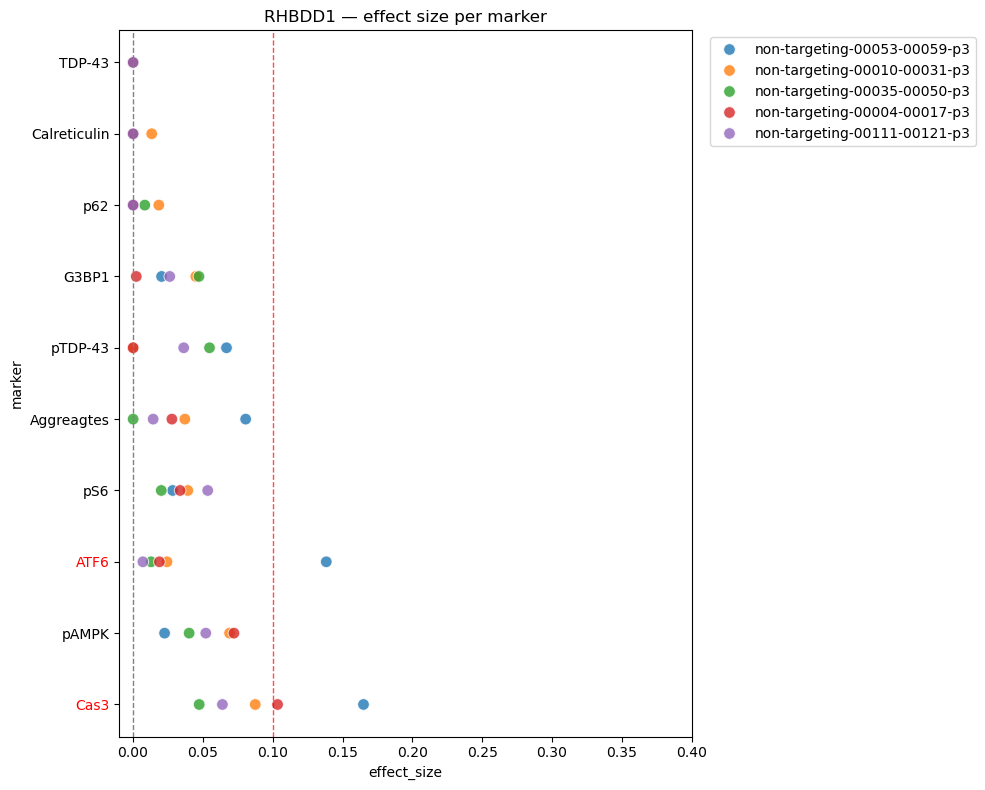

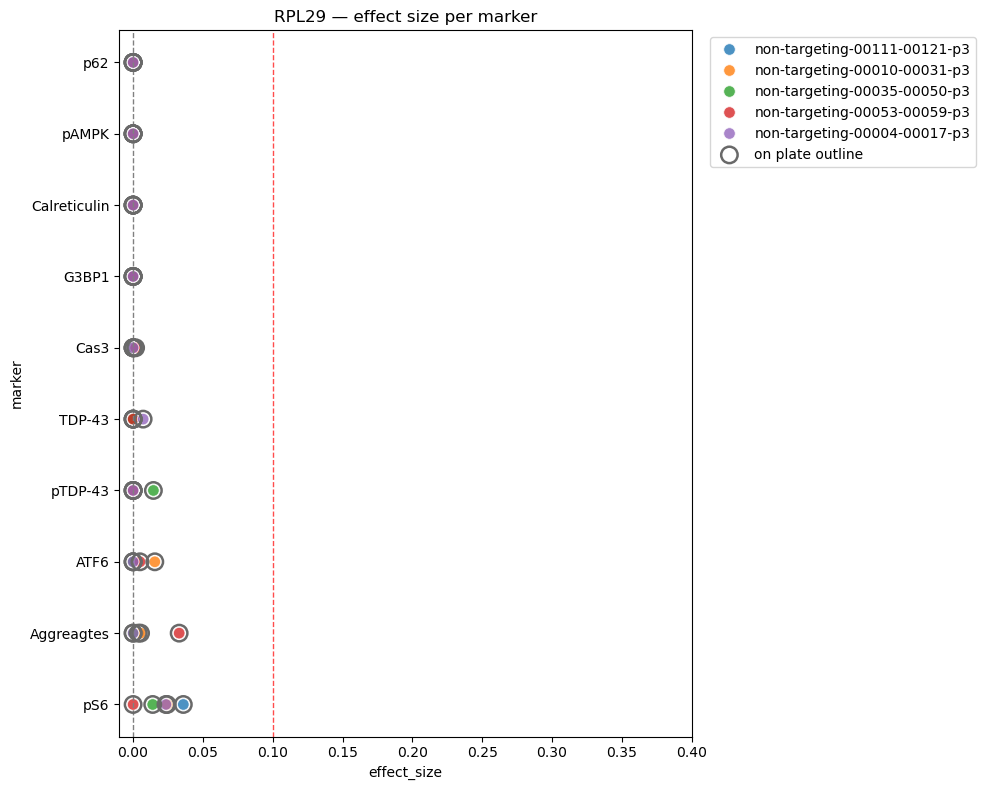

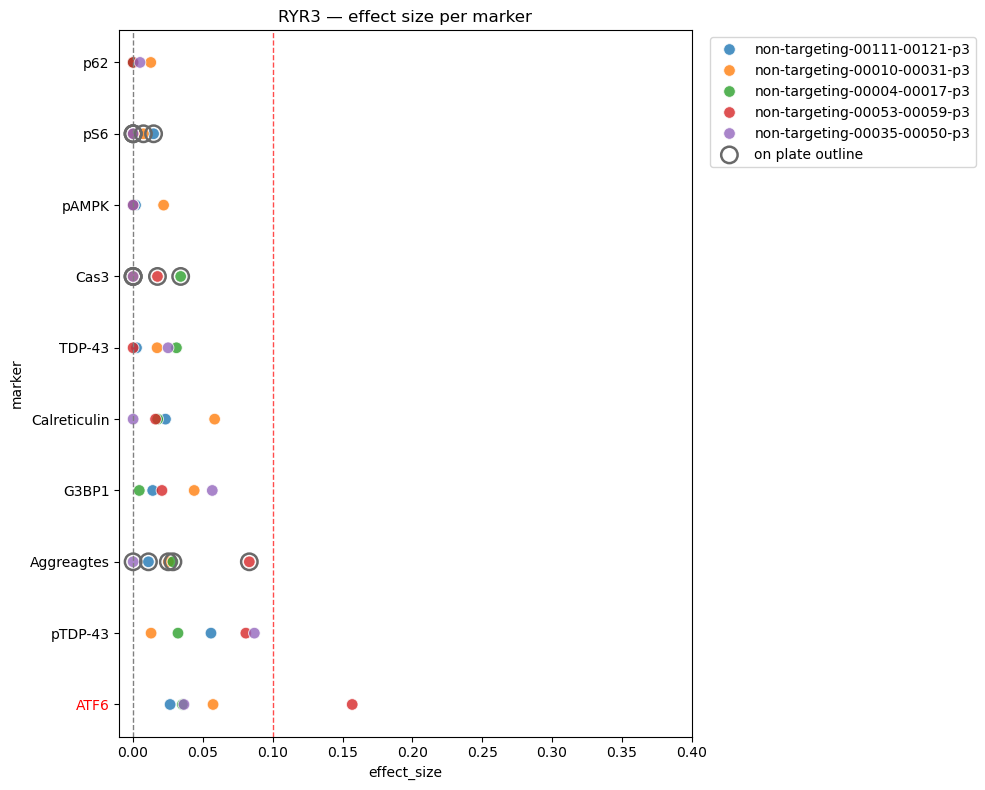

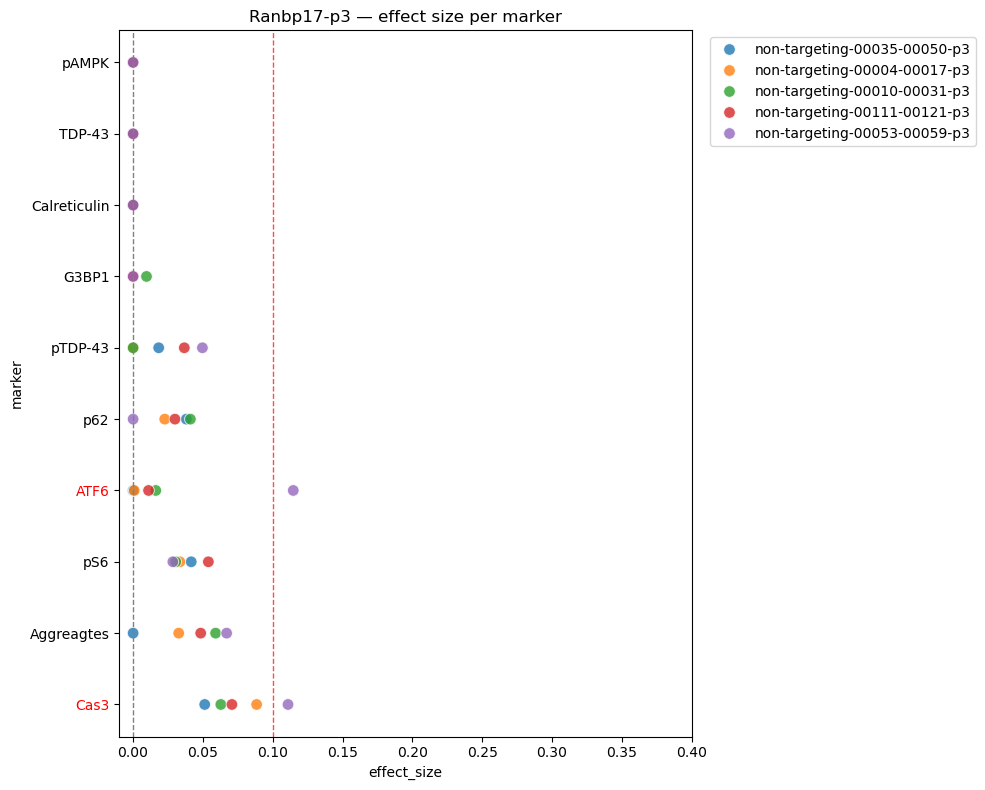

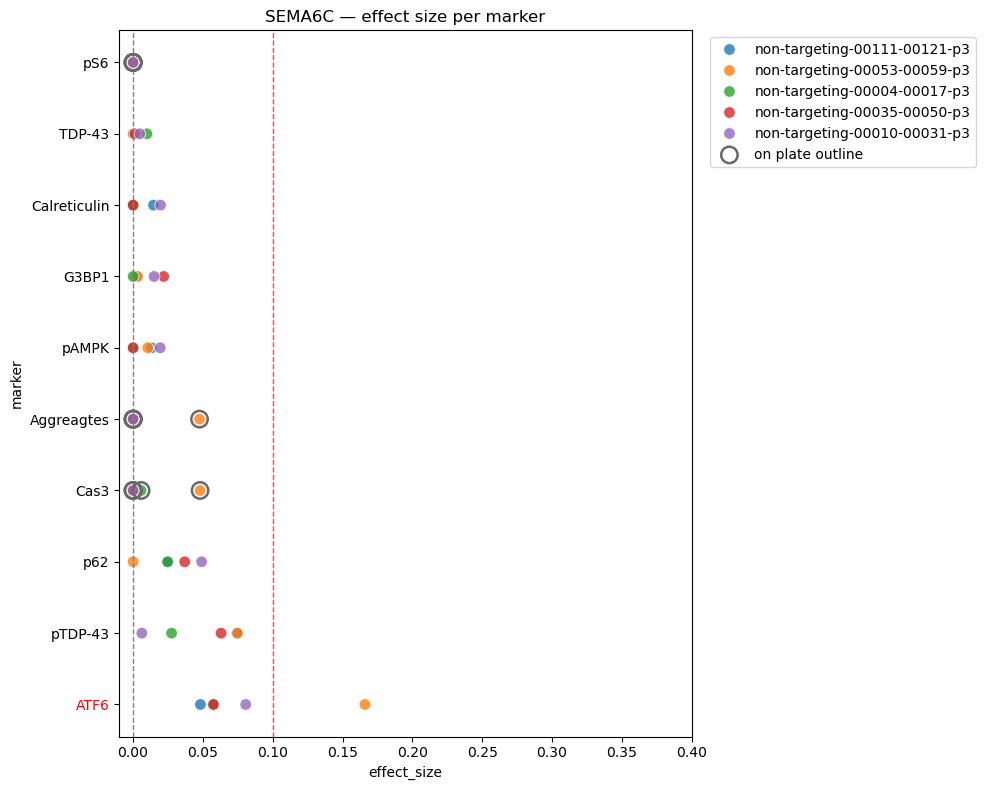

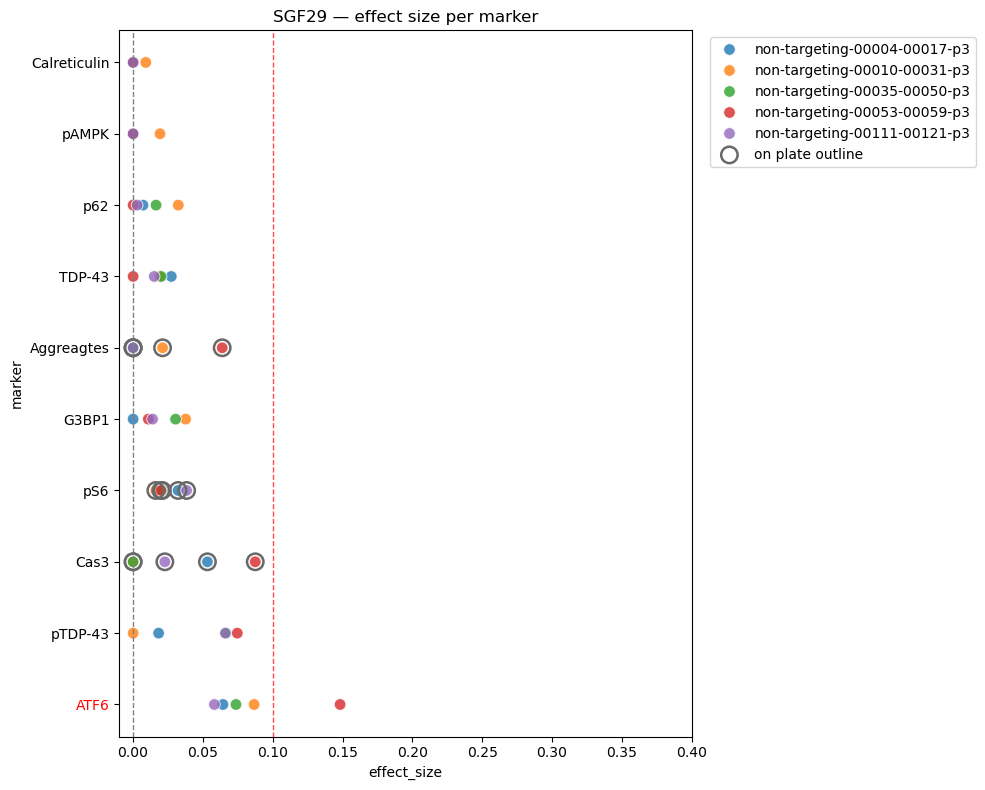

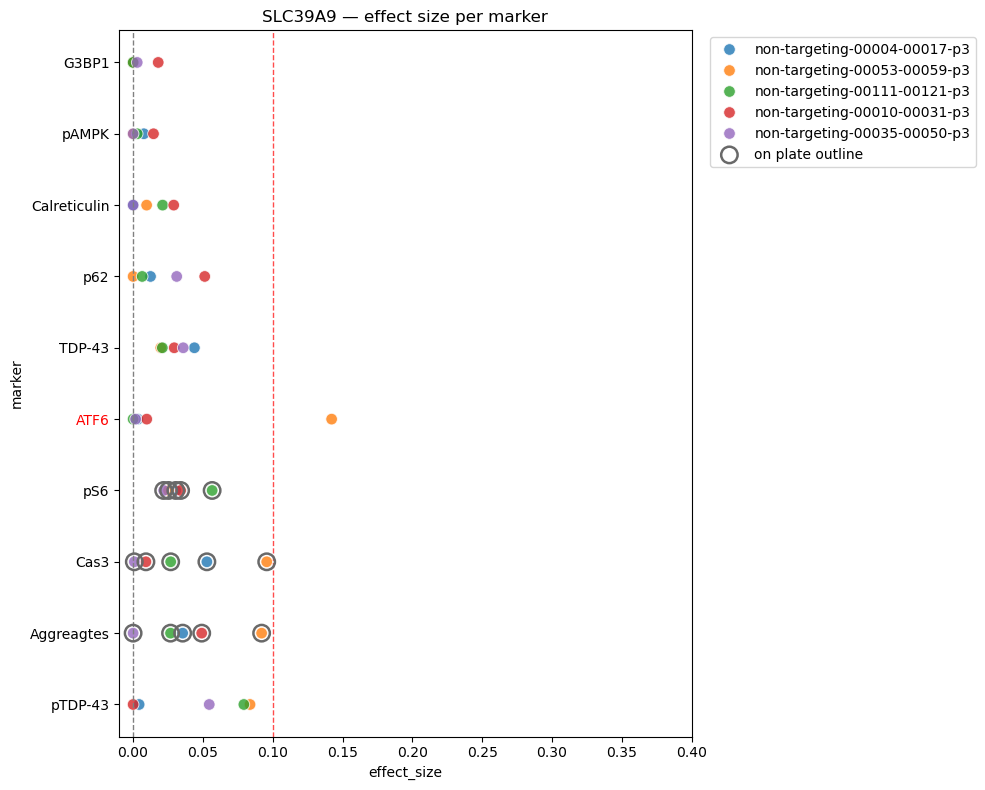

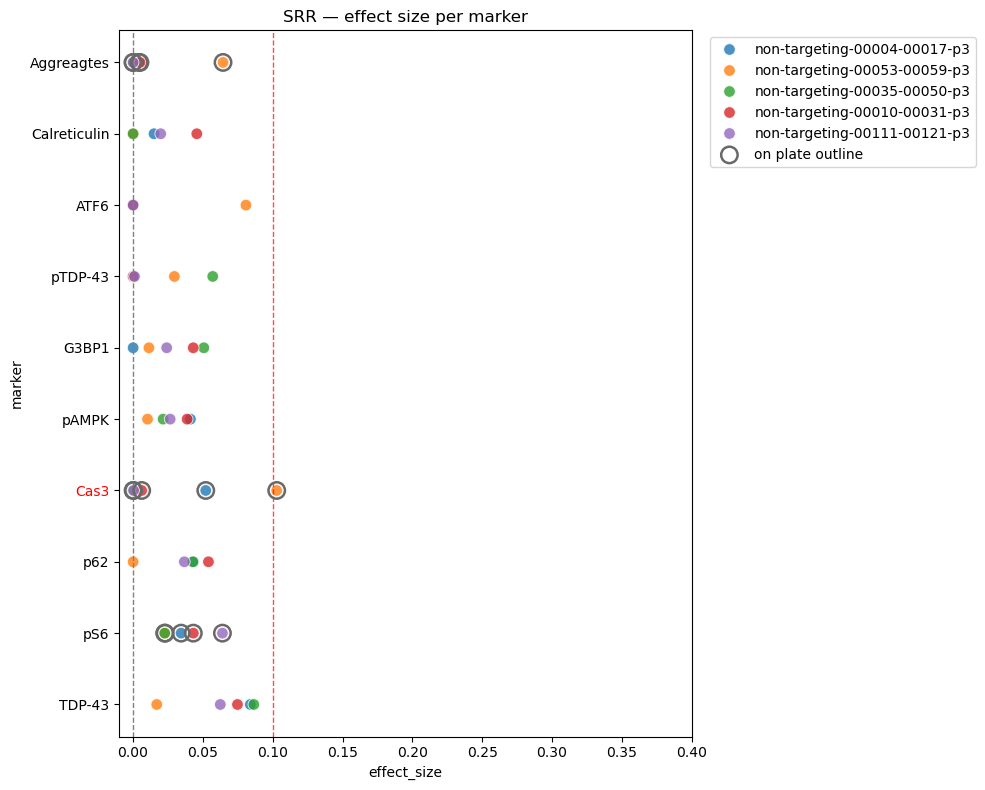

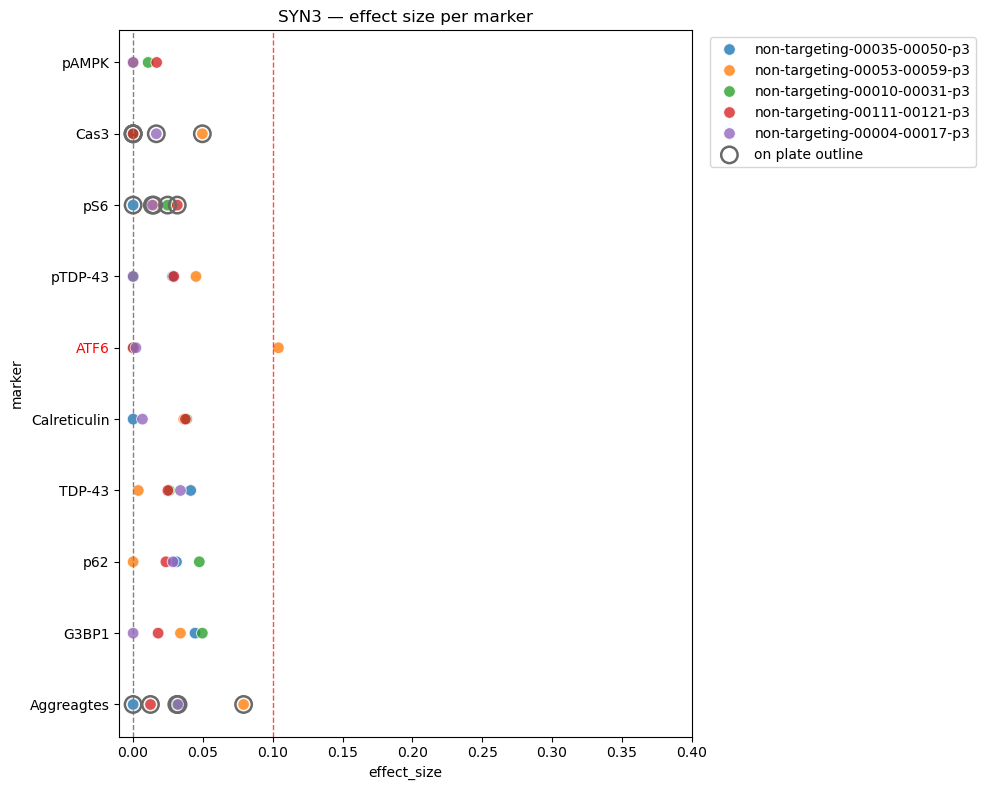

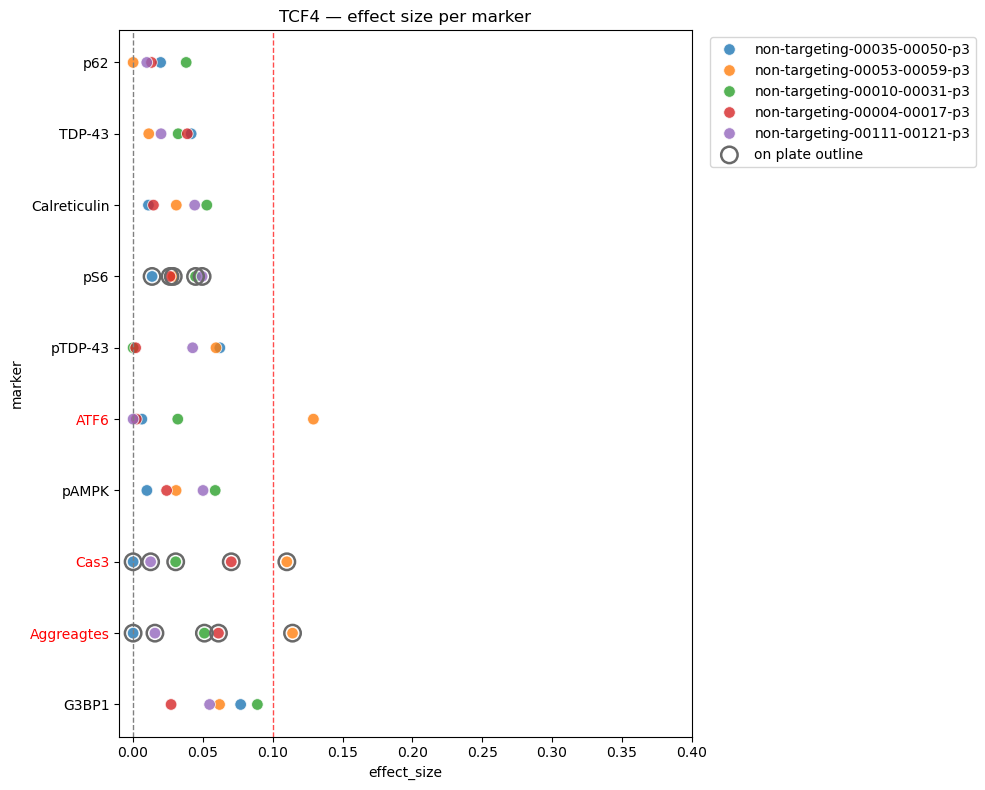

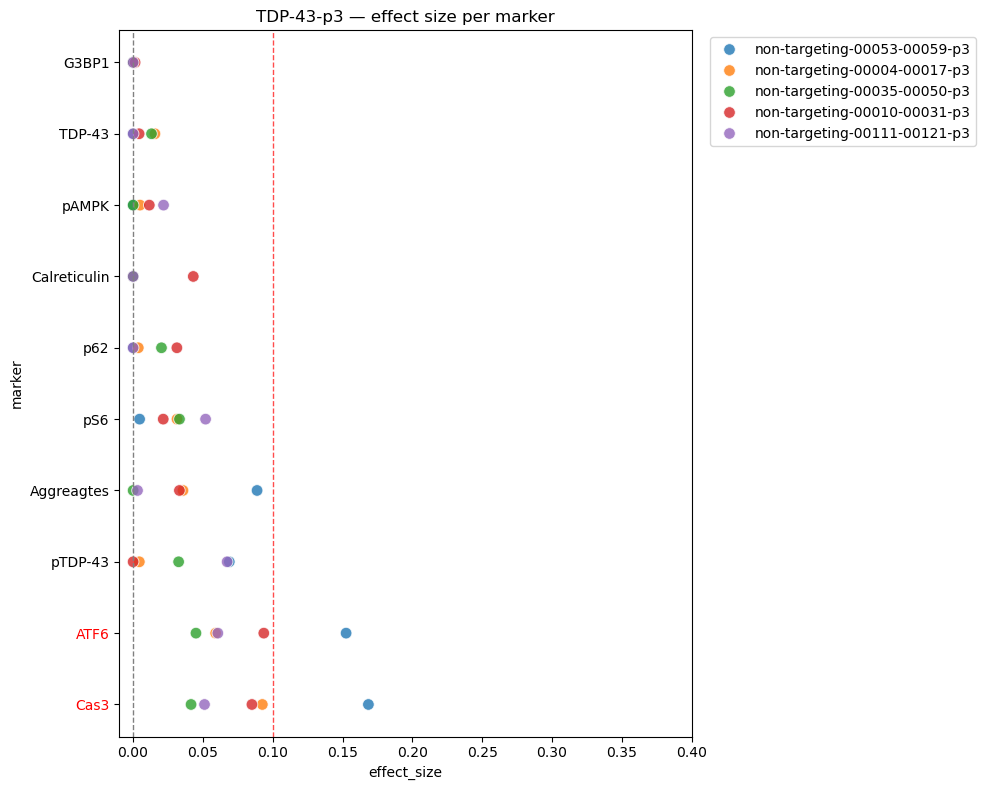

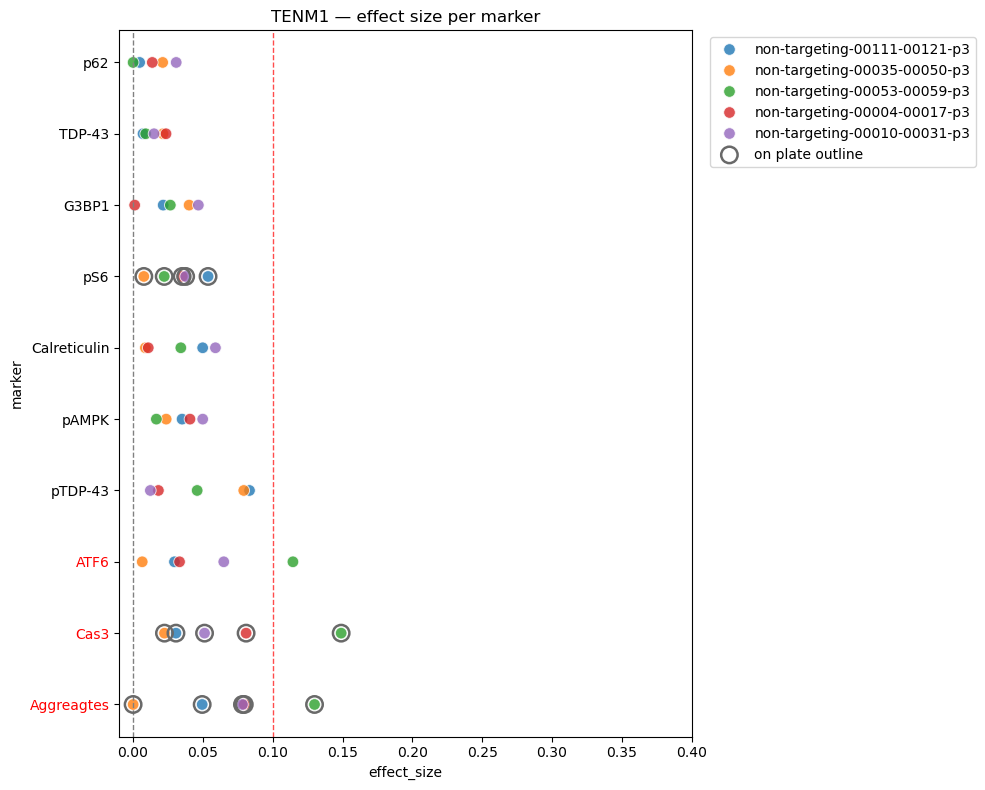

In [13]:
# per kd scatter of effect size vs markers, coloured by control:
dir_name = "per_kd_scatter"
os.makedirs(os.path.join(PLOTS_DIR, dir_name), exist_ok=True)
for kd in sorted(data["kd"].unique()):
    subset = filter_data(
        data,
        kds=[kd],
        cell_lines=["C9"],
        batches=["batch1"],
        controls=None,
        clip_negative=True,
    )

    plot_scatter(
        subset, x="effect_size", y="marker", hue="control",
        title=f"{kd} — effect size per marker",
        save_as=f"per_kd_scatter/scatter_{kd}_all_controls_grey_outline.png",
        xlim=(-0.01, 0.4),
        vline_threshold=0.1,
        grey_outline=True,
    );

## 6. Interaction plot (paired across two groups)

Generic pairing: pick `pair_column` (e.g. `cell_line` to pair `CTL` ↔ `C9`, or `control` to pair two non-targeting controls). The two values listed in `pair_values=(left, right)` are joined with a connecting line; the rest is filtered out.

In [ ]:
def plot_interaction(
    df: pd.DataFrame,
    pair_column: str = "cell_line",
    pair_values: tuple = ("CTL", "C9"),
    y: str = "kd",            # one row per group on the y-axis
    value: str = "effect_size",
    sort_by: str = "mean",     # "mean" | "left" | "right" | "delta"
    figsize=(9, 8),
    colors=("darkcyan", "tomato"),
    title: Optional[str] = None,
    save_as: Optional[str] = None,
):
    left_val, right_val = pair_values
    sub = df[df[pair_column].isin(pair_values)].copy()
    if sub.empty:
        print("No rows after filtering."); return None
    pivot = sub.pivot_table(index=y, columns=pair_column, values=value, aggfunc="mean")
    pivot = pivot.dropna(subset=list(pair_values))
    if pivot.empty:
        print("No rows have both sides of the pair."); return None

    if sort_by == "mean":
        order = ((pivot[left_val] + pivot[right_val]) / 2).sort_values(ascending=False).index
    elif sort_by == "left":
        order = pivot[left_val].sort_values(ascending=False).index
    elif sort_by == "right":
        order = pivot[right_val].sort_values(ascending=False).index
    elif sort_by == "delta":
        order = (pivot[right_val] - pivot[left_val]).sort_values(ascending=False).index
    else:
        order = pivot.index
    pivot = pivot.loc[order]

    fig, ax = plt.subplots(figsize=figsize)
    ys = range(len(pivot))
    for i, (_, row) in enumerate(pivot.iterrows()):
        ax.plot([row[left_val], row[right_val]], [i, i], color="grey", alpha=0.5, lw=2, zorder=1)
        ax.scatter(row[left_val],  i, facecolors="none", edgecolors=colors[0], s=110, lw=2, zorder=3)
        ax.scatter(row[right_val], i, facecolors=colors[1], edgecolors=colors[1], s=110, zorder=3)

    ax.set_yticks(list(ys))
    ax.set_yticklabels(pivot.index)
    ax.invert_yaxis()
    ax.set_xlabel(value); ax.set_ylabel(y)
    ax.set_title(title or f"{left_val} vs {right_val} ({pair_column})")
    legend = [
        plt.Line2D([0],[0], marker="o", linestyle="", markerfacecolor="none", markeredgecolor=colors[0], label=left_val),
        plt.Line2D([0],[0], marker="o", linestyle="", markerfacecolor=colors[1], markeredgecolor=colors[1], label=right_val),
    ]
    ax.legend(handles=legend, loc="best")
    plt.tight_layout()
    if save_as:
        fig.savefig(os.path.join(PLOTS_DIR, save_as), dpi=200, bbox_inches="tight")
    return fig, ax, pivot

In [15]:
# Example: CTL vs C9 interaction for one marker (across KDs)
if {"CTL", "C9"}.issubset(data["cell_line"].unique()):
    subset = filter_data(
        data,
        markers=["TDP-43"],
        batches=["weighted"],
        clip_negative=True,
    )
    plot_interaction(
        subset,
        pair_column="cell_line", pair_values=("CTL", "C9"),
        y="kd",
        title="TDP-43: CTL vs C9 across KDs",
        save_as="interaction_TDP43_CTL_vs_C9.png",
    )
else:
    print("Only one cell line in this plate — skipping CTL/C9 interaction example.")

Only one cell line in this plate — skipping CTL/C9 interaction example.


## 7. Delta heatmap (right − left)

Generic version of the original "C9 − CTL delta" heatmap. Works for any two values of any column.

In [16]:
def plot_delta_heatmap(
    df: pd.DataFrame,
    pair_column: str = "cell_line",
    pair_values: tuple = ("CTL", "C9"),
    y: str = "marker",
    x: str = "kd",
    value: str = "effect_size",
    vmax: float = 0.5,
    cmap: str = "RdBu_r",
    sort_markers_by_group: bool = True,
    figsize=(12, 6),
    title: Optional[str] = None,
    mask_abs_below: Optional[float] = None,   # white-out cells with |delta| < threshold
    save_as: Optional[str] = None,
):
    left_val, right_val = pair_values
    sub = df[df[pair_column].isin(pair_values)]
    if sub.empty:
        print("No rows after filtering."); return None

    left  = sub[sub[pair_column] == left_val ].pivot_table(index=y, columns=x, values=value, aggfunc="mean")
    right = sub[sub[pair_column] == right_val].pivot_table(index=y, columns=x, values=value, aggfunc="mean")
    delta = (right - left).dropna(how="all").dropna(axis=1, how="all")

    if sort_markers_by_group and y == "marker":
        order = sorted(delta.index, key=lambda m: (MARKER_TO_GROUP.get(m, "Other"), m))
        delta = delta.reindex(order)

    plot_delta = delta.copy()
    if mask_abs_below is not None:
        plot_delta = plot_delta.mask(plot_delta.abs() < mask_abs_below)

    cbar_label = f"Δ {value} ({right_val} − {left_val})"
    if mask_abs_below is not None:
        cbar_label += f"  (|x|<{mask_abs_below} masked)"

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        plot_delta, ax=ax, cmap=cmap, center=0,
        vmin=-vmax, vmax=vmax,
        cbar_kws={"label": cbar_label},
    )

    if mask_abs_below is not None:
        cbar = ax.collections[0].colorbar
        if cbar is not None:
            lo, hi = cbar.ax.get_ylim()
            for thr in (mask_abs_below, -mask_abs_below):
                if min(lo, hi) <= thr <= max(lo, hi):
                    cbar.ax.axhline(thr, color="k", linewidth=1)

    ax.set_title(title or f"Δ {value}: {right_val} − {left_val}")
    ax.set_xlabel(x); ax.set_ylabel(y)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_as:
        fig.savefig(os.path.join(PLOTS_DIR, save_as), dpi=200, bbox_inches="tight")
    return fig, ax, delta

In [17]:
if {"CTL", "C9"}.issubset(data["cell_line"].unique()):
    subset = filter_data(
        data,
        batches=["weighted"],
        exclude_markers=["DAPI"],
        clip_negative=True,
    )
    plot_delta_heatmap(
        subset,
        pair_column="cell_line", pair_values=("CTL", "C9"),
        y="marker", x="kd",
        mask_abs_below=0.1,
        title="Δ effect size (C9 − CTL) — all markers × all KDs",
        save_as="delta_heatmap_C9_minus_CTL.png",
    );

## 8. Free-form: any (x, y) at the row level

Because `data` is a tidy long DataFrame, anything you can pivot/group, you can plot. A few quick patterns:

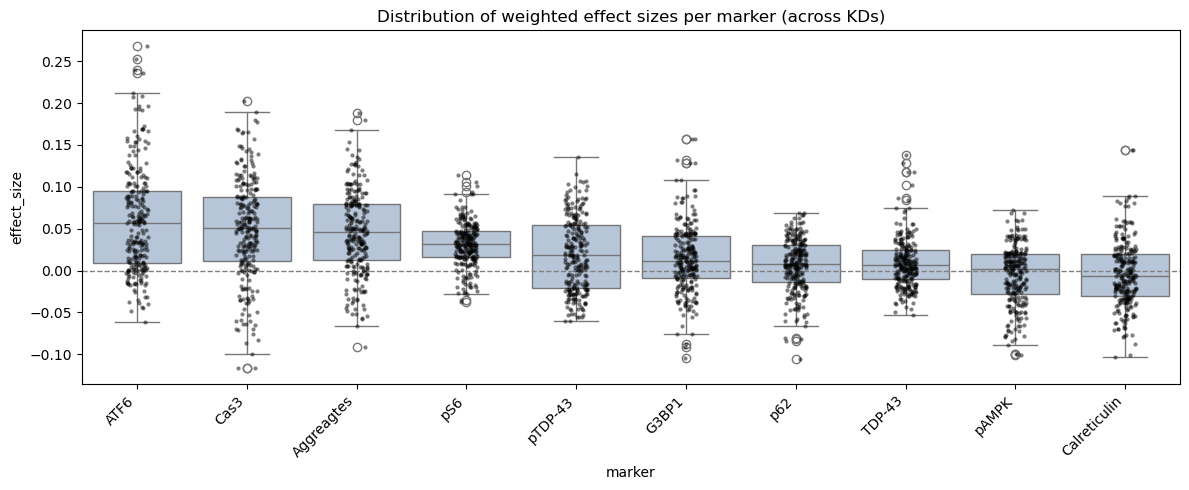

In [18]:
# Distribution of effect sizes per marker (all KDs, all batches)
subset = filter_data(data, batches=["weighted"], cell_lines=["C9"], exclude_markers=["DAPI"])
fig, ax = plt.subplots(figsize=(12, 5))
order = subset.groupby("marker")["effect_size"].median().sort_values(ascending=False).index
sns.boxplot(data=subset, x="marker", y="effect_size", order=order, ax=ax, color="lightsteelblue")
sns.stripplot(data=subset, x="marker", y="effect_size", order=order, ax=ax,
              color="black", size=3, alpha=0.5)
ax.axhline(0, color="grey", lw=1, ls="--")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of weighted effect sizes per marker (across KDs)")
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "box_marker_distribution.png"), dpi=200, bbox_inches="tight");
plt.show()

In [19]:
# Top-N hits: largest weighted effect for each marker
TOP_N = 10
subset = filter_data(data, batches=["weighted"], cell_lines=["C9"], exclude_markers=["DAPI"], clip_negative=True)
top = (subset
       .sort_values("effect_size", ascending=False)
       .groupby("marker")
       .head(TOP_N)
       .loc[:, ["marker", "kd", "control", "effect_size"]]
       .reset_index(drop=True))
top.head(20)

,marker,kd,control,effect_size
0,ATF6,MYCN,non-targeting-00053-00059-p3,0.267642
1,ATF6,NADSYN1,non-targeting-00053-00059-p3,0.253059
2,ATF6,NOMO2,non-targeting-00053-00059-p3,0.239412
3,ATF6,OSBP2,non-targeting-00053-00059-p3,0.236239
4,ATF6,NCDN,non-targeting-00053-00059-p3,0.212580
5,ATF6,POLI,non-targeting-00053-00059-p3,0.208916
6,ATF6,DCX,non-targeting-00053-00059-p3,0.206954
7,Cas3,NOMO2,non-targeting-00053-00059-p3,0.202492
8,ATF6,GNAL,non-targeting-00053-00059-p3,0.196559
9,ATF6,DLG5,non-targeting-00053-00059-p3,0.196011
